# 9842 - Interest Rate and Credit Models
## Homework 1 - Group E

**Group name:** Group E  
**Group members:** Lin, Yueqi; Smalhout, Paolo Chai; Tuzes, Daniel  
**HW #:** 1

---

### Submission rules (copied from the assignment handout)
- Email by the due date/time to: nikos.fxcube@gmail.com and Stephanie.Wang.MFE@gmail.com, and cc your group members.
- Late submission will not be accepted.
- Only Jupyter Notebooks will be accepted.
- Extra points for well commented code.
- Email subject: `9842HW1_GroupE`
- Filename: `9842HW1_GroupE.ipynb`


## Notes
- All plots are shown inline in this notebook. No external image files are generated.
- Parts (B) and (C) use the FRB nominal yield curve CSV (source (i) in the assignment). Put the CSV next to this notebook and set `FRB_CSV_PATH` below.


In [ ]:
# Ensure the figure output directory exists (idempotent).
import os
os.makedirs("report/output", exist_ok=True)

# Part (A) - Closed form for the yield

We are given the Nelson-Siegel instantaneous forward curve
$$
y(s) = \beta_0 + \beta_1 e^{-\lambda s} + \beta_2 \, \lambda s \, e^{-\lambda s}, \qquad \lambda > 0,
$$
and the yield definition
$$
Y(T) = \frac{1}{T}\int_0^T y(s)\,ds.
$$

We derive a closed form for $Y(T)$ and explain the role of the parameters.


## Derivation

Start from
$$
Y(T) = \frac{1}{T}\int_0^T \left(\beta_0 + \beta_1 e^{-\lambda s} + \beta_2 \lambda s e^{-\lambda s}\right)\,ds.
$$

Compute the two nontrivial integrals:
$$
\begin{aligned}
\int_0^T e^{-\lambda s}\,ds
&= \left[-\frac{1}{\lambda}e^{-\lambda s}\right]_0^T
= \frac{1-e^{-\lambda T}}{\lambda}, \\
\int_0^T \lambda s e^{-\lambda s}\,ds
&= \left[-s e^{-\lambda s}\right]_0^T + \int_0^T e^{-\lambda s}\,ds
= -T e^{-\lambda T} + \frac{1-e^{-\lambda T}}{\lambda}.
\end{aligned}
$$

Substitute back:
$$
\begin{aligned}
Y(T)
&= \beta_0 + \frac{\beta_1}{T}\frac{1-e^{-\lambda T}}{\lambda}
+ \frac{\beta_2}{T}\left(-T e^{-\lambda T} + \frac{1-e^{-\lambda T}}{\lambda}\right) \\
&= \beta_0 + \beta_1\frac{1-e^{-\lambda T}}{\lambda T}
+ \beta_2\left(\frac{1-e^{-\lambda T}}{\lambda T} - e^{-\lambda T}\right).
\end{aligned}
$$

Define the loadings
$$
A_1(T;\lambda)=\frac{1-e^{-\lambda T}}{\lambda T}, \qquad
A_2(T;\lambda)=\frac{1-e^{-\lambda T}}{\lambda T}-e^{-\lambda T},
$$
so the yield is
$$
Y(T)=\beta_0+\beta_1 A_1(T;\lambda)+\beta_2 A_2(T;\lambda).
$$


## Interpretation of the parameters

- **Level ($\beta_0$)**: since as $T\to\infty$, $A_1(T;\lambda)\to 0$ and $A_2(T;\lambda)\to 0$ ,
  $$
  \lim_{T\to\infty} Y(T)=\beta_0.
  $$
  This is the long-run level of the curve.

- **Short end / slope ($\beta_1$)**: as , $A_1(T;\lambda)\to 1$ and $A_2(T;\lambda)\to 0$, so
  $$
  \lim_{T\to 0} Y(T)=\beta_0+\beta_1.
  $$
  If $\beta_1>0$, the curve is usually downward-sloping. The short end $(\beta_0+\beta_1)$ starts above the long-run level $(\beta_0)$ and decays down to it.

  If $\beta_1<0$, the curve is usually upward-sloping. The short end $(\beta_0+\beta_1)$ starts below the long-run level $(\beta_0)$ and rises up to it.

- **Curvature ($\beta_2$)**: for both $T\to 0$ and $T\to\infty$, $A_2(T;\lambda)\to 0$. However, $A_2(T;\lambda)$ peaks at medium maturities.
  Hence $\beta_2$ mainly controls mid-maturity curvature (a hump if $\beta_2>0$; a dip if $\beta_2<0$).

- **Scale ($\lambda$)**: increasing $\lambda$ makes the exponentials decay faster, concentrating slope/curvature effects at shorter maturities.
  A rough curvature timescale is $T \approx 1/\lambda$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Example plot parameters (matching the captions we use below)
beta_0 = 1.0
beta_1 = -1.0
beta_2 = 3.0
lam = 1.0

# Maturity grid (avoid T=0 division)
T_min = 1e-4
T_max = 10.0
T = np.linspace(T_min, T_max, 2000)

def A1(T, lam):
    """Loading for beta_1."""
    T = np.asarray(T, dtype=float)
    return (1.0 - np.exp(-lam * T)) / (lam * T)

def A2(T, lam):
    """Loading for beta_2."""
    T = np.asarray(T, dtype=float)
    return (1.0 - np.exp(-lam * T)) / (lam * T) - np.exp(-lam * T)

def Y_NS(T, beta_0, beta_1, beta_2, lam):
    """Nelson-Siegel zero-coupon yield Y(T), continuously compounded."""
    return beta_0 + beta_1 * A1(T, lam) + beta_2 * A2(T, lam)

A1_vals = A1(T, lam)
A2_vals = A2(T, lam)
Y_vals = Y_NS(T, beta_0, beta_1, beta_2, lam)

print("Y(0+) approx beta_0 + beta_1 =", beta_0 + beta_1)
print("Y(10) =", float(Y_NS(10.0, beta_0, beta_1, beta_2, lam)))
print("Y(infty) -> beta_0 =", beta_0)


Y(0+) approx beta_0 + beta_1 = 0.0
Y(10) = 1.19985472022476
Y(infty) -> beta_0 = 1.0


FileNotFoundError: [Errno 2] No such file or directory: 'report/output/gsw_loadings.pdf'

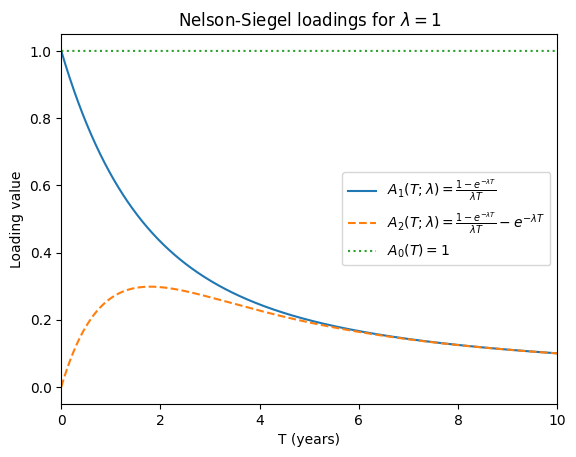

In [2]:
# Plot loadings A1 and A2 (inline)

fig, ax = plt.subplots()
ax.plot(T, A1_vals, label=r"$A_1(T;\lambda) = \frac{1-e^{-\lambda T}}{\lambda T}$")
ax.plot(T, A2_vals, label=r"$A_2(T;\lambda) = \frac{1-e^{-\lambda T}}{\lambda T} - e^{-\lambda T}$", linestyle="--")
# add constant loading for beta_0
ax.plot(T, np.ones_like(T), label=r"$A_0(T) = 1$", linestyle=":")
ax.set_xlim(0, T_max)
ax.set_xlabel("T (years)")
ax.set_ylabel("Loading value")
ax.set_title(r"Nelson-Siegel loadings for $\lambda = 1$")
ax.legend()
plt.savefig(os.path.join("report/output/gsw_loadings.pdf"))
plt.show()
plt.close(fig)


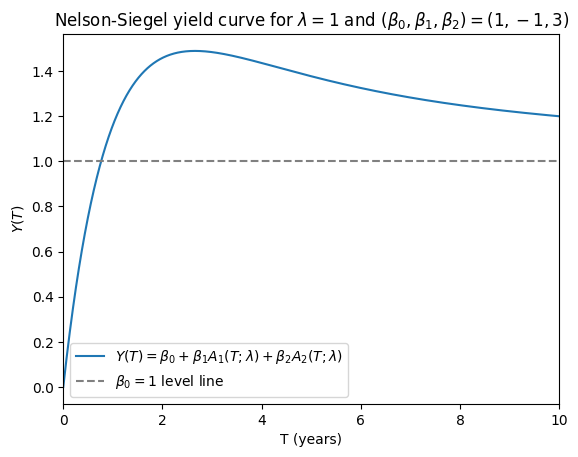

In [ ]:
# Plot the yield curve Y(T) (inline)
fig, ax = plt.subplots()
ax.plot(T, Y_vals, label=r"$Y(T) = \beta_0 + \beta_1 A_1(T;\lambda) + \beta_2 A_2(T;\lambda)$")
ax.set_xlim(0, T_max)
ax.set_xlabel("T (years)")
ax.set_ylabel(r"$Y(T)$")
ax.set_title(r"Nelson-Siegel yield curve for $\lambda = 1$ and $(\beta_0,\beta_1,\beta_2)=(1,-1,3)$")
# add a constant line at 1 for reference
ax.axhline(1.0, color="gray", linestyle="--", label=r"$\beta_0 = 1$ level line")
ax.legend()
plt.savefig(os.path.join("report/output/gsw_yields_example.pdf"))
plt.show()
plt.close(fig)


# Part (B) - Data construction (daily, since Jan 1, 2016)

**Goal:** build a daily time series of zero-coupon yields at maturities
$T \in \{0.25, 0.5, 1, 2, 3, 5, 7, 10\}$ years.

**Data source:** FRB/GSW Svensson parameters from ``feds200628.csv``.
The file provides daily Nelson-Siegel-Svensson (NSS) parameters
$(\beta_0, \beta_1, \beta_2, \beta_3, \tau_1, \tau_2)$, from which we
evaluate the zero-coupon yield at any maturity $T$:

$$
Y^{\text{NSS}}(T) = \beta_0
  + \beta_1 \frac{1-e^{-T/\tau_1}}{T/\tau_1}
  + \beta_2 \left(\frac{1-e^{-T/\tau_1}}{T/\tau_1} - e^{-T/\tau_1}\right)
  + \beta_3 \left(\frac{1-e^{-T/\tau_2}}{T/\tau_2} - e^{-T/\tau_2}\right).
$$

**Why zero-coupon (not par) yields?** CMT par yields embed coupon effects and
conflate discounting across horizons, introducing bias when fitting a
discount-curve model like NS. The GSW dataset provides zero-coupon yields
directly, avoiding this issue.

In [ ]:
import os, warnings
import pandas as pd
import numpy as np

# Load the FRB / GSW Svensson parameter file.
# The first 9 rows are comments; row 10 is the header.
frb = pd.read_csv("feds200628.csv", skiprows=9, header=0)
frb["Date"] = pd.to_datetime(frb["Date"])
frb = frb.sort_values("Date").reset_index(drop=True)

# TAU2 uses -999.99 as a sentinel for "not applicable"
frb["TAU2"] = frb["TAU2"].replace(-999.99, np.nan)

print(f"Loaded feds200628.csv: {len(frb)} rows, "
      f"{frb['Date'].iloc[0].date()} to {frb['Date'].iloc[-1].date()}")

Loaded feds200628.csv: 16868 rows, 1961-06-14 to 2026-02-06


In [ ]:
TENORS = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10], dtype=float)

def sven_yield_continuous(T, beta0, beta1, beta2, beta3, tau1, tau2):
    """Svensson/GSW zero-coupon yield Y(T), continuously compounded.
    Vectorized over rows; handles NaN tau2 gracefully."""
    T = np.asarray(T, dtype=float)
    beta0, beta1, beta2, beta3 = (
        np.asarray(v, dtype=float) for v in (beta0, beta1, beta2, beta3))
    tau1, tau2 = np.asarray(tau1, dtype=float), np.asarray(tau2, dtype=float)
    x1 = T / tau1
    A1 = (1.0 - np.exp(-x1)) / x1
    A2 = A1 - np.exp(-x1)
    y = beta0 + beta1 * A1 + beta2 * A2
    valid = np.isfinite(tau2) & (tau2 > 0) & np.isfinite(beta3)
    if np.any(valid):
        x2 = np.where(valid, T / np.where(valid, tau2, 1.0), 1.0)
        A3 = (1.0 - np.exp(-x2)) / x2 - np.exp(-x2)
        y = y + np.where(valid, beta3 * A3, 0.0)
    return y

# Build the panel: 2016-01-01 onwards
frb_cut = frb.loc[frb["Date"] >= pd.Timestamp("2016-01-01")].copy()
panel = pd.DataFrame({"Date": frb_cut["Date"].values})
for T_ in TENORS:
    panel[f"Y_{T_:g}"] = sven_yield_continuous(
        T_, frb_cut["BETA0"].values, frb_cut["BETA1"].values,
        frb_cut["BETA2"].values, frb_cut["BETA3"].values,
        frb_cut["TAU1"].values, frb_cut["TAU2"].values)
panel = panel.dropna(subset=[f"Y_{TENORS[0]:g}"]).reset_index(drop=True)

tenor_cols = [f"Y_{t:g}" for t in TENORS]
print(f"Panel: {len(panel)} business days, "
      f"{panel['Date'].iloc[0].date()} to {panel['Date'].iloc[-1].date()}")
panel[tenor_cols].describe().round(4)

Panel: 2524 business days, 2016-01-04 to 2026-02-06


,Y_0.25,Y_0.5,Y_1,Y_2,Y_3,Y_5,Y_7,Y_10
count,2524.0000,2524.0000,2524.0000,2524.0000,2524.0000,2524.0000,2524.0000,2524.0000
mean,2.3486,2.3436,2.3283,2.3238,2.3535,2.4598,2.5800,2.7445
std,1.9096,1.8476,1.7419,1.5747,1.4521,1.2978,1.2196,1.1716
min,-0.0525,0.0502,0.0554,0.1020,0.1272,0.2218,0.3413,0.5202
25%,0.5423,0.5961,0.6757,0.8740,1.0599,1.3655,1.5499,1.7910
50%,1.9066,1.9715,2.0455,2.2550,2.3032,2.3866,2.4561,2.6022
75%,4.2882,4.2152,4.0743,3.8785,3.7669,3.7306,3.8271,3.9116
max,5.7916,5.5740,5.4322,5.1524,5.0041,4.8946,4.9308,5.0584


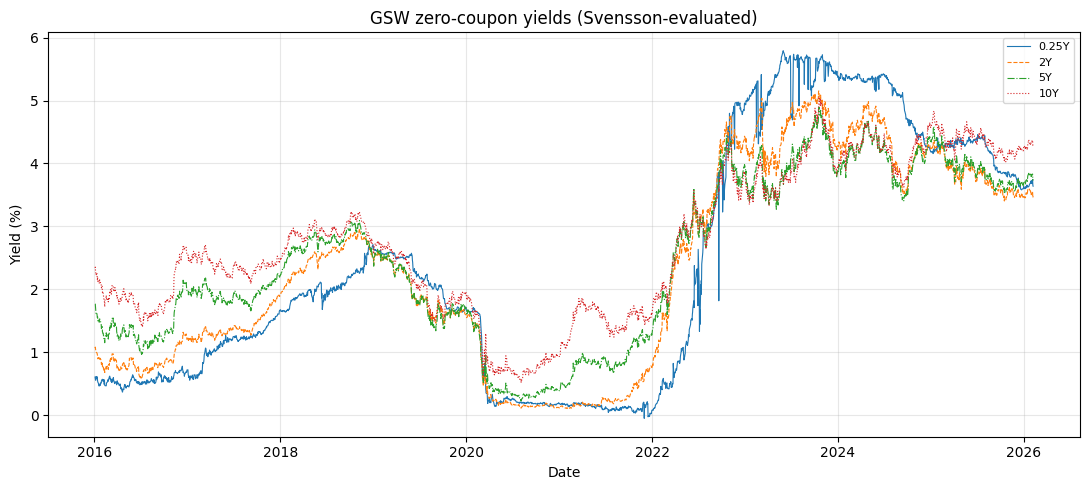

In [ ]:
import matplotlib.pyplot as plt

# Time-series plot of selected zero-coupon yields
fig, ax = plt.subplots(figsize=(11, 5))
for T_, style in [(0.25, "-"), (2, "--"), (5, "-."), (10, ":")]:
    ax.plot(panel["Date"], panel[f"Y_{T_:g}"], style, linewidth=0.8,
            label=f"{T_:g}Y")
ax.set_ylabel("Yield (%)")
ax.set_xlabel("Date")
ax.set_title("GSW zero-coupon yields (Svensson-evaluated)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_yields.pdf"))
plt.show()
# save as pdf

plt.close(fig)

# Part (C) - Cross-sectional calibration (curve fitting)

For each business day $t$ in the panel, we fit the three-parameter Nelson-Siegel yield

$$
\hat{Y}(T;\, \beta_0, \beta_1, \beta_2, \lambda)
= \beta_0
+ \beta_1 \frac{1-e^{-\lambda T}}{\lambda T}
+ \beta_2 \left(\frac{1-e^{-\lambda T}}{\lambda T} - e^{-\lambda T}\right)
$$

to the observed zero-coupon yields $\{Y_t(T_i)\}_{i=1}^{8}$ at $T \in \{0.25, 0.5, 1, 2, 3, 5, 7, 10\}$ by minimizing

$$
\min_{\beta_0,\,\beta_1,\,\beta_2,\,\lambda}
\sum_{i=1}^{8} \bigl(Y_t(T_i) - \hat{Y}(T_i;\,\beta_0,\beta_1,\beta_2,\lambda)\bigr)^2.
$$

**Key observation.** For any *fixed* $\lambda$, the model is linear in $(\beta_0, \beta_1, \beta_2)$, so the betas can be obtained in closed form by OLS. We only need to search over the single scalar $\lambda$.

Three approaches for choosing $\lambda$:

- **(a) Grid search** over $\lambda \in [0.05,\, 5.0]$ with conditional OLS.
- **(b) Fixed $\lambda$** chosen by minimizing the median RMSE across all days.
- **(c) Full nonlinear optimization** over all four parameters jointly.

In [ ]:
import numpy.linalg as npl
from scipy.optimize import minimize

def ns_loadings(T, lam):
    """NS factor loadings A1, A2 for given lambda."""
    x = np.asarray(lam) * np.asarray(T, dtype=float)
    A1 = (1.0 - np.exp(-x)) / x
    return A1, A1 - np.exp(-x)

def ns_curve(T, b0, b1, b2, lam):
    """Evaluate NS yield curve at maturities T."""
    A1, A2 = ns_loadings(T, lam)
    return b0 + b1 * A1 + b2 * A2

def fit_ns_ols(y, T, lam):
    """OLS for (b0, b1, b2) conditional on lambda.
    Returns (beta, yhat, rmse, sse)."""
    A1, A2 = ns_loadings(T, lam)
    X = np.column_stack([np.ones(len(T)), A1, A2])
    beta = npl.lstsq(X, y, rcond=None)[0]
    r = y - X @ beta
    sse = float(r @ r)
    return beta, X @ beta, float(np.sqrt(sse / len(T))), sse

def fit_ns_grid(y, T, lam_grid):
    """Grid search over lambda with conditional OLS.
    Returns (beta, yhat, rmse, sse, lam)."""
    best_sse, best = np.inf, None
    for lam in lam_grid:
        beta, yhat, rmse, sse = fit_ns_ols(y, T, lam)
        if sse < best_sse:
            best_sse = sse
            best = (beta.copy(), yhat.copy(), rmse, sse, lam)
    return best

def fit_ns_nlopt(y, T):
    """Joint L-BFGS-B over (b0, b1, b2, lambda)."""
    b0, _, _, _, l0 = fit_ns_grid(y, T, np.linspace(0.1, 3.0, 30))
    x0 = np.array([*b0, l0])
    def obj(x):
        r = y - ns_curve(T, x[0], x[1], x[2], x[3])
        return float(r @ r)
    res = minimize(obj, x0, method="L-BFGS-B",
                   bounds=[(None,None)]*3 + [(0.01, 10.0)])
    beta, lam = res.x[:3], res.x[3]
    yhat = ns_curve(T, *beta, lam)
    sse = float(np.sum((y - yhat)**2))
    return beta, yhat, float(np.sqrt(sse/len(T))), sse, lam

def fit_ns_constrained(y, T, lam_bounds=(0.2, 2.0),
                       b0_bounds=(0, 10), b12_bounds=(-5, 5)):
    """Nonlinear NS fit with box constraints on all parameters."""
    b_init, _, _, _, l_init = fit_ns_grid(
        y, T, np.linspace(lam_bounds[0], lam_bounds[1], 50))
    x0 = np.array([np.clip(b_init[0], *b0_bounds),
                    np.clip(b_init[1], *b12_bounds),
                    np.clip(b_init[2], *b12_bounds),
                    np.clip(l_init, *lam_bounds)])
    def obj(x):
        r = y - ns_curve(T, x[0], x[1], x[2], x[3])
        return float(r @ r)
    res = minimize(obj, x0, method="L-BFGS-B",
                   bounds=[b0_bounds, b12_bounds, b12_bounds, lam_bounds])
    beta, lam = res.x[:3], res.x[3]
    yhat = ns_curve(T, *beta, lam)
    sse = float(np.sum((y - yhat)**2))
    return beta, yhat, float(np.sqrt(sse/len(T))), sse, lam

def nearest_idx(dt):
    """Index of nearest date in panel."""
    return int(np.argmin(np.abs(panel["Date"] - dt)))

lam_grid = np.logspace(np.log10(0.05), np.log10(5.0), 120)
print("Fitting functions defined.")

Fitting functions defined.


In [ ]:
# Run grid search + nonlinear optimization on every day.
Y_mat = panel[tenor_cols].to_numpy(dtype=float)
dates = panel["Date"].values
N = len(panel)

grid_params  = np.empty((N, 4))  # b0, b1, b2, lam
grid_rmse    = np.empty(N)
nlopt_params = np.empty((N, 4))
nlopt_rmse   = np.empty(N)

for i in range(N):
    y = Y_mat[i]
    bg, _, rg, _, lg = fit_ns_grid(y, TENORS, lam_grid)
    grid_params[i]  = [*bg, lg]
    grid_rmse[i]    = rg
    bn, _, rn, _, ln = fit_ns_nlopt(y, TENORS)
    nlopt_params[i] = [*bn, ln]
    nlopt_rmse[i]   = rn

df_grid = pd.DataFrame({"date": dates,
    "beta0": grid_params[:,0], "beta1": grid_params[:,1],
    "beta2": grid_params[:,2], "lam": grid_params[:,3], "rmse": grid_rmse})
df_nlopt = pd.DataFrame({"date": dates,
    "beta0": nlopt_params[:,0], "beta1": nlopt_params[:,1],
    "beta2": nlopt_params[:,2], "lam": nlopt_params[:,3], "rmse": nlopt_rmse})

print(f"Grid search: {N} days, median RMSE = {np.median(grid_rmse):.4f}%")
print(f"Nonlinear opt: {N} days, median RMSE = {np.median(nlopt_rmse):.4f}%")

Grid search: 2524 days, median RMSE = 0.0016%
Nonlinear opt: 2524 days, median RMSE = 0.0015%


In [ ]:
# (b) Fixed lambda chosen by cross-validation (fully vectorized).
lam_cv_grid = np.linspace(0.05, 3.0, 200)
median_rmses = np.empty(len(lam_cv_grid))
for j, lam in enumerate(lam_cv_grid):
    A1, A2 = ns_loadings(TENORS, lam)
    X = np.column_stack([np.ones(len(TENORS)), A1, A2])
    Betas = (npl.solve(X.T @ X, X.T) @ Y_mat.T).T
    Yhat = (X @ Betas.T).T
    median_rmses[j] = np.median(np.sqrt(np.mean((Y_mat - Yhat)**2, axis=1)))

lam_fixed = lam_cv_grid[np.argmin(median_rmses)]
print(f"Optimal fixed lambda = {lam_fixed:.4f} "
      f"(median RMSE = {median_rmses.min():.4f}%)")

# Vectorized fit with fixed lambda
A1_f, A2_f = ns_loadings(TENORS, lam_fixed)
X_f = np.column_stack([np.ones(len(TENORS)), A1_f, A2_f])
Betas_f = (npl.solve(X_f.T @ X_f, X_f.T) @ Y_mat.T).T
Yhat_f = (X_f @ Betas_f.T).T
rmse_f = np.sqrt(np.mean((Y_mat - Yhat_f)**2, axis=1))

df_fixed = pd.DataFrame({"date": dates,
    "beta0": Betas_f[:,0], "beta1": Betas_f[:,1],
    "beta2": Betas_f[:,2], "lam": lam_fixed, "rmse": rmse_f})
print(f"Fixed-lambda done: median RMSE = {df_fixed['rmse'].median():.4f}%")

Optimal fixed lambda = 0.4058 (median RMSE = 0.0137%)
Fixed-lambda done: median RMSE = 0.0137%


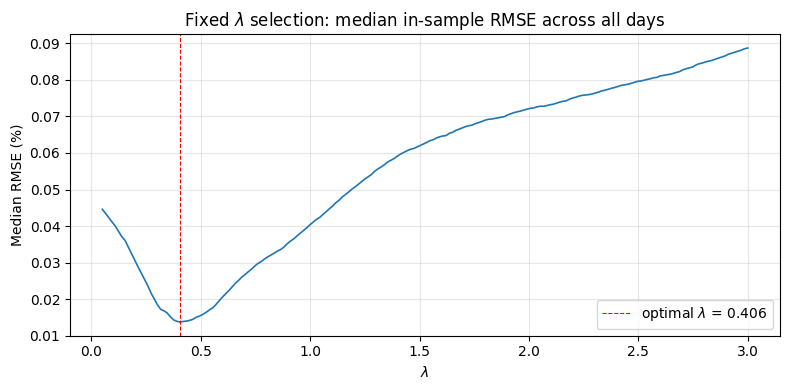

In [ ]:
# In-sample grid search curve: median RMSE vs fixed lambda
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lam_cv_grid, median_rmses, linewidth=1.2)
ax.axvline(lam_fixed, color="red", linestyle="--", linewidth=0.8,
           label=f"optimal $\\lambda$ = {lam_fixed:.3f}")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("Median RMSE (%)")
ax.set_title("Fixed $\\lambda$ selection: median in-sample RMSE across all days")
plt.savefig(os.path.join("report/output/gsw_fixed_lambda.pdf"))
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show(); plt.close(fig)


## C(i) - Observed vs. fitted curves on representative days

We pick dates spanning diverse curve regimes: steep normal, COVID stress, mid-hiking hump, and a recent mild slope.

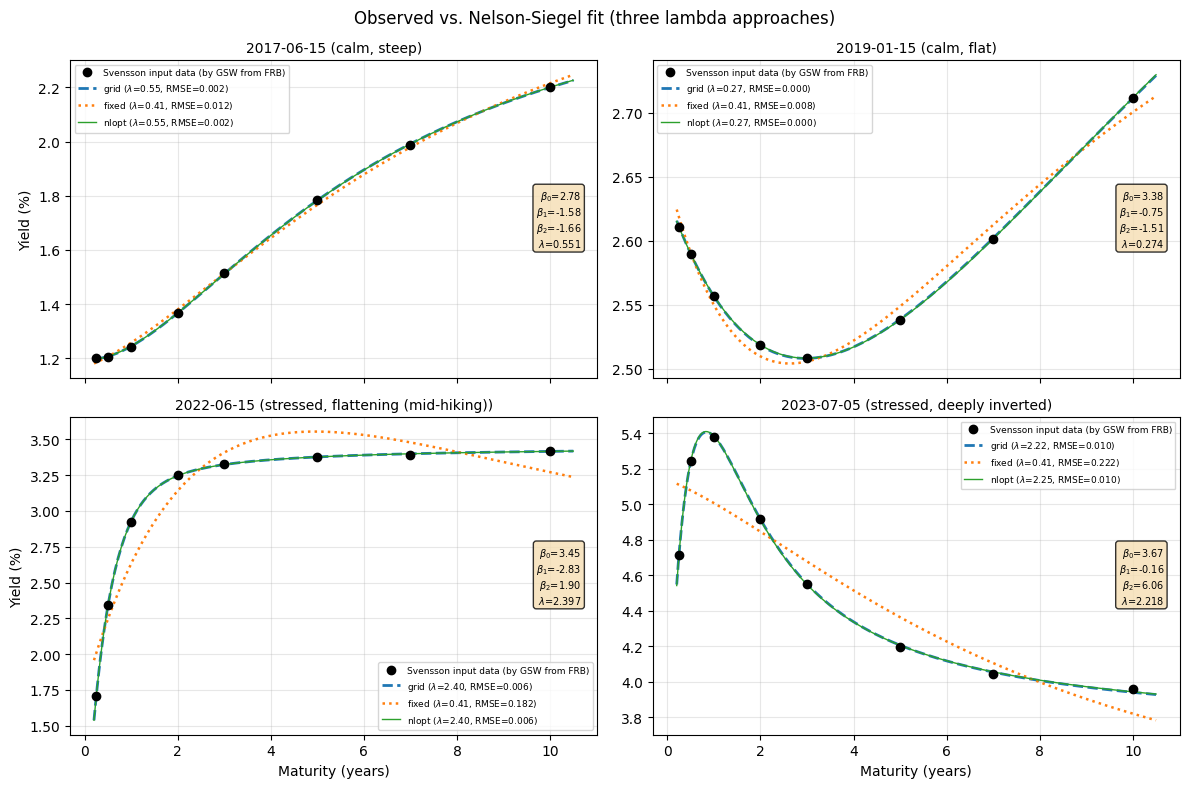

In [ ]:
rep_dates = {"2017-06-15": "calm, steep", 
             "2019-01-15": "calm, flat", 
             "2022-06-15": "stressed, flattening (mid-hiking)",
             "2023-07-05": "stressed, deeply inverted"}

T_fine = np.linspace(0.2, 10.5, 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for k, (d_str, desc) in enumerate(rep_dates.items()):
    ax = axes[k]
    idx = nearest_idx(pd.Timestamp(d_str))
    y_obs = panel.iloc[idx][tenor_cols].to_numpy(dtype=float)
    rg, rf, rn = df_grid.iloc[idx], df_fixed.iloc[idx], df_nlopt.iloc[idx]

    ax.plot(TENORS, y_obs, "ko", markersize=6, label="Svensson input data (by GSW from FRB)", zorder=5)
    ax.plot(T_fine, ns_curve(T_fine, rg["beta0"], rg["beta1"], rg["beta2"], rg["lam"]),
            "--", linewidth=2, label=f"grid ($\\lambda$={rg['lam']:.2f}, RMSE={rg['rmse']:.3f})")
    ax.plot(T_fine, ns_curve(T_fine, rf["beta0"], rf["beta1"], rf["beta2"], rf["lam"]),
            ":", linewidth=1.8, label=f"fixed ($\\lambda$={lam_fixed:.2f}, RMSE={rf['rmse']:.3f})")
    ax.plot(T_fine, ns_curve(T_fine, rn["beta0"], rn["beta1"], rn["beta2"], rn["lam"]),
            "-", linewidth=1, label=f"nlopt ($\\lambda$={rn['lam']:.2f}, RMSE={rn['rmse']:.3f})")

    # Add parameter annotations (grid-search values, right side, vertically centered)
    txt = (f'$\\beta_0$={rg["beta0"]:.2f}\n'
           f'$\\beta_1$={rg["beta1"]:.2f}\n'
           f'$\\beta_2$={rg["beta2"]:.2f}\n'
           f'$\\lambda$={rg["lam"]:.3f}')
    ax.text(0.97, 0.5, txt, transform=ax.transAxes, fontsize=7,
            va="center", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.8))

    ax.set_title(f"{panel.iloc[idx]['Date'].date()} ({desc})", fontsize=10)
    ax.legend(fontsize=6.5); ax.grid(True, alpha=0.3)
    if k >= 2: ax.set_xlabel("Maturity (years)")
    if k % 2 == 0: ax.set_ylabel("Yield (%)")

fig.suptitle("Observed vs. Nelson-Siegel fit (three lambda approaches)", fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_fits.pdf"))
plt.show(); plt.close(fig)

## C(ii) - Comparison of lambda approaches

We compare the three approaches by examining RMSE distributions and lambda stability over time.

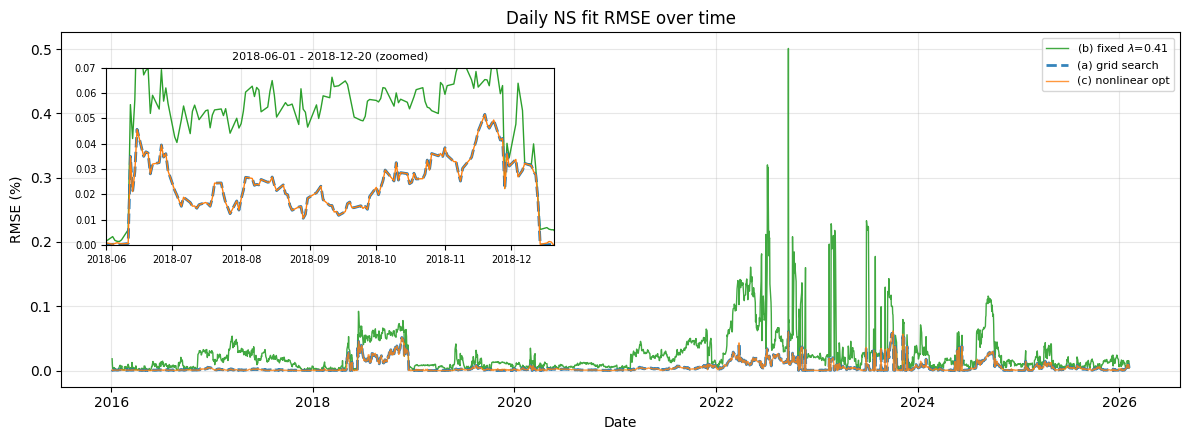

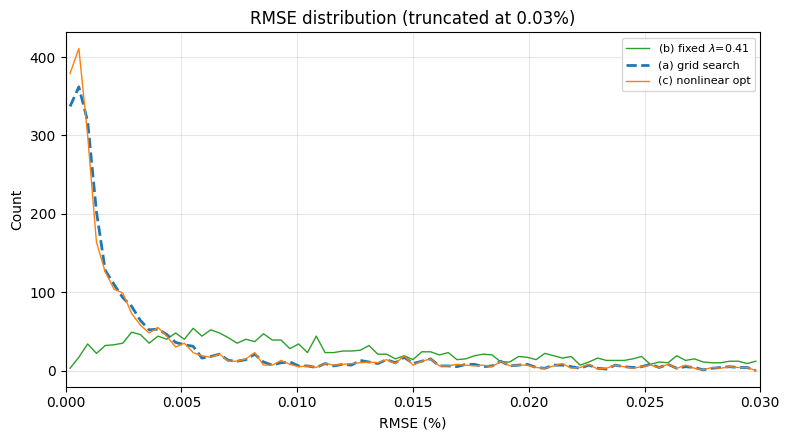

,approach,mean RMSE,median RMSE,max RMSE,mean lam,std lam
0,(a) grid search,0.0053,0.0016,0.0615,0.6416,0.5739
1,(b) fixed lam=0.41,0.0261,0.0137,0.5009,0.4058,0.0000
2,(c) nonlinear opt,0.0053,0.0015,0.0615,0.6408,0.5616


In [ ]:
# RMSE time series with inset
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df_fixed["date"], df_fixed["rmse"], "-", linewidth=1.0,
        color="C2", label=f"(b) fixed $\\lambda$={lam_fixed:.2f}", alpha=0.9)
ax.plot(df_grid["date"], df_grid["rmse"], "--", linewidth=2,
        color="C0", label="(a) grid search", alpha=0.9)
ax.plot(df_nlopt["date"], df_nlopt["rmse"], "-", linewidth=1,
        color="C1", label="(c) nonlinear opt", alpha=0.8)
ax.set_ylabel("RMSE (%)"); ax.set_title("Daily NS fit RMSE over time")
ax.set_xlabel("Date")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axins = ax.inset_axes([0.04, 0.4, 0.40, 0.50])
mask = df_grid["date"] < pd.Timestamp("2022-01-01")
axins.plot(df_fixed.loc[mask, "date"], df_fixed.loc[mask, "rmse"], "-", lw=1.0, color="C2")
axins.plot(df_grid.loc[mask, "date"], df_grid.loc[mask, "rmse"], "--", lw=2.0, color="C0")
axins.plot(df_nlopt.loc[mask, "date"], df_nlopt.loc[mask, "rmse"], "-", lw=1, color="C1")
axins.set_ylim(0.0, 0.07)
axins.set_xlim(pd.Timestamp("2018-06-01"), pd.Timestamp("2018-12-20"))
axins.tick_params(labelsize=7)
axins.set_title("2018-06-01 - 2018-12-20 (zoomed)", fontsize=8)
axins.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_rmse_lambda_time.pdf"))
plt.show(); plt.close(fig)

# RMSE distribution (lines, truncated at 0.1%)
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 0.03, 80)
bc = 0.5 * (bins[:-1] + bins[1:])
ax.plot(bc, np.histogram(df_fixed["rmse"], bins)[0], "-", lw=1, color="C2",
        label=f"(b) fixed $\\lambda$={lam_fixed:.2f}")
ax.plot(bc, np.histogram(df_grid["rmse"], bins)[0], "--", lw=2, color="C0",
        label="(a) grid search")
ax.plot(bc, np.histogram(df_nlopt["rmse"], bins)[0], "-", lw=1, color="C1",
        label="(c) nonlinear opt")
ax.set_xlabel("RMSE (%)"); ax.set_ylabel("Count")
ax.set_xlim(0, 0.03)
ax.set_title("RMSE distribution (truncated at 0.03%)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_rmse_dist.pdf"))
plt.show(); plt.close(fig)

# Summary table
pd.DataFrame({
    "approach": ["(a) grid search", f"(b) fixed lam={lam_fixed:.2f}", "(c) nonlinear opt"],
    "mean RMSE": [df_grid["rmse"].mean(), df_fixed["rmse"].mean(), df_nlopt["rmse"].mean()],
    "median RMSE": [df_grid["rmse"].median(), df_fixed["rmse"].median(), df_nlopt["rmse"].median()],
    "max RMSE": [df_grid["rmse"].max(), df_fixed["rmse"].max(), df_nlopt["rmse"].max()],
    "mean lam": [df_grid["lam"].mean(), lam_fixed, df_nlopt["lam"].mean()],
    "std lam": [df_grid["lam"].std(), 0.0, df_nlopt["lam"].std()],
}).round(4)

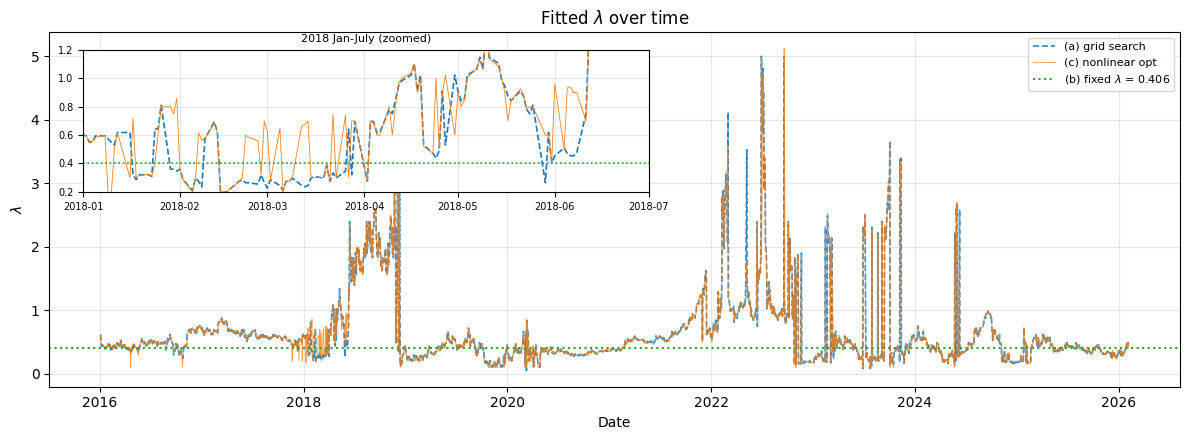

In [ ]:
# Lambda time series: grid search vs nonlinear optimization
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df_grid["date"], df_grid["lam"], "--", linewidth=1.2,
        color="C0", label="(a) grid search", alpha=0.9)
ax.plot(df_nlopt["date"], df_nlopt["lam"], "-", linewidth=0.6,
        color="C1", label="(c) nonlinear opt", alpha=0.8)
ax.axhline(lam_fixed, color="C2", linestyle=":", linewidth=1.5,
           label=f"(b) fixed $\\lambda$ = {lam_fixed:.3f}")
ax.set_ylabel(r"$\lambda$"); ax.set_title("Fitted $\\lambda$ over time")
ax.set_xlabel("Date")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axins = ax.inset_axes([0.03, 0.55, 0.50, 0.40])
mask = (df_grid["date"] >= pd.Timestamp("2016-01-01")) & (df_grid["date"] < pd.Timestamp("2018-07-01"))
axins.plot(df_grid.loc[mask, "date"], df_grid.loc[mask, "lam"], "--", lw=1.2, color="C0")
axins.plot(df_nlopt.loc[mask, "date"], df_nlopt.loc[mask, "lam"], "-", lw=0.6, color="C1")
axins.axhline(lam_fixed, color="C2", linestyle=":", linewidth=1.2)
axins.set_ylim(0.2, 1.2)
axins.set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2018-07-01"))
axins.tick_params(labelsize=7)
axins.set_title("2018 Jan-July (zoomed)", fontsize=8)
axins.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_lambda_time.pdf"))
plt.show(); plt.close(fig)

## C(iii) - Time-series stability of the NS factors

We examine the time series of $(\beta_0, \beta_1, \beta_2)$ from the grid-search approach: summary statistics, rolling volatility, and correlations.

In [ ]:
beta_cols = ["beta0", "beta1", "beta2"]

# Summary statistics
print("=== Factor summary statistics ===")
display(df_grid[beta_cols].describe().round(4))

# Full-sample correlations
corr = df_grid[beta_cols].corr()
print("\n=== Full-sample correlation matrix ===")
display(corr.round(4))

# Rolling 60-day volatility by regime
vols = {c: df_grid[c].rolling(60, min_periods=30).std() for c in beta_cols}
mask_calm = df_grid["date"] < pd.Timestamp("2022-01-01")
mask_stress = (df_grid["date"] >= pd.Timestamp("2022-01-01")) & (df_grid["date"] < pd.Timestamp("2024-01-01"))

vol_summary = pd.DataFrame({
    "2016-2021 median": {c: vols[c][mask_calm].median() for c in beta_cols},
    "2016-2021 max":    {c: vols[c][mask_calm].max() for c in beta_cols},
    "2022-2023 median": {c: vols[c][mask_stress].median() for c in beta_cols},
    "2022-2023 max":    {c: vols[c][mask_stress].max() for c in beta_cols},
})
print("\n=== Rolling 60-day volatility by regime ===")
display(vol_summary.round(4))

=== Factor summary statistics ===


,beta0,beta1,beta2
count,2524.0000,2524.0000,2524.0000
mean,3.4445,-1.1068,-1.9321
std,1.3949,1.2667,2.1498
min,0.7403,-17.6446,-30.8362
25%,2.5821,-1.9420,-3.1344
50%,3.0400,-1.3176,-2.0946
75%,4.3904,-0.3354,-1.3142
max,23.4050,2.0905,12.1775



=== Full-sample correlation matrix ===


,beta0,beta1,beta2
beta0,1.0000,0.1178,-0.5077
beta1,0.1178,1.0000,0.0248
beta2,-0.5077,0.0248,1.0000



=== Rolling 60-day volatility by regime ===


,2016-2021 median,2016-2021 max,2022-2023 median,2022-2023 max
beta0,0.1532,0.7114,0.5693,3.5275
beta1,0.1709,0.9077,0.8303,3.5379
beta2,0.3116,1.0084,2.2424,6.7150


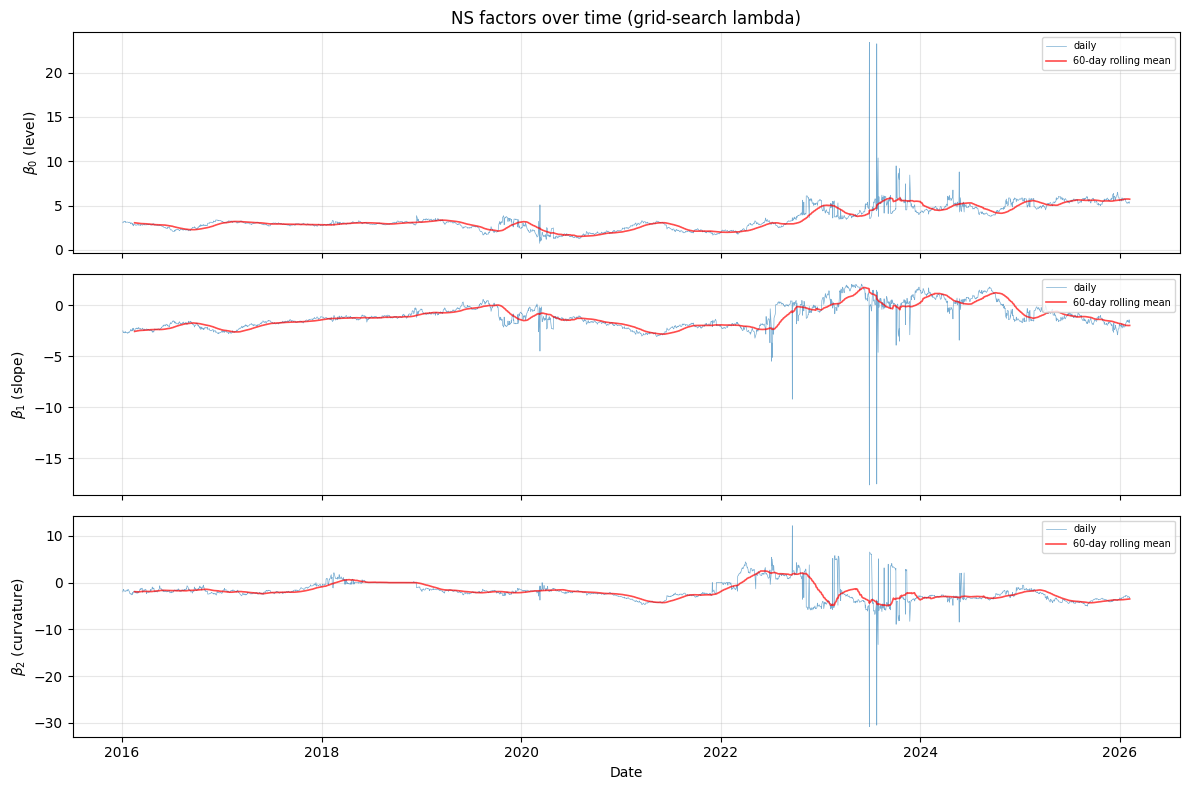

In [ ]:
# Time series of NS factors (grid search)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
labels = [r"$\beta_0$ (level)", r"$\beta_1$ (slope)", r"$\beta_2$ (curvature)"]
for j, col in enumerate(beta_cols):
    ax = axes[j]
    ax.plot(df_grid["date"], df_grid[col], linewidth=0.5, alpha=0.6, label="daily")
    ax.plot(df_grid["date"], df_grid[col].rolling(60, min_periods=30).mean(),
            linewidth=1.2, color="red", alpha=0.7, label="60-day rolling mean")
    ax.set_ylabel(labels[j])
    ax.legend(fontsize=7, loc="upper right"); ax.grid(True, alpha=0.3)
axes[0].set_title("NS factors over time (grid-search lambda)")
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_factors_grid.pdf"))
plt.show(); plt.close(fig)

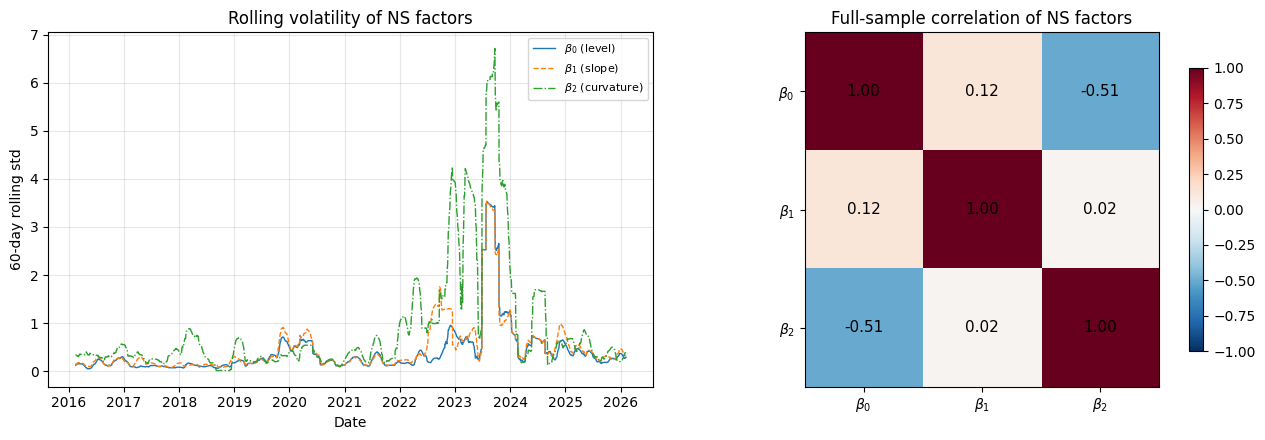

In [ ]:
# Rolling volatility (60-day) and correlation of NS factors
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
vols = {c: df_grid[c].rolling(60, min_periods=30).std() for c in beta_cols}
sorted_cols = sorted(vols, key=lambda c: vols[c].median())
styles = {sorted_cols[0]: "-", sorted_cols[1]: "--", sorted_cols[2]: "-."}
blabels = {"beta0": r"$\beta_0$ (level)", "beta1": r"$\beta_1$ (slope)",
           "beta2": r"$\beta_2$ (curvature)"}
for c in sorted_cols:
    ax.plot(df_grid["date"], vols[c], styles[c], lw=1.0, label=blabels[c])
ax.set_ylabel("60-day rolling std")
ax.set_xlabel("Date")
ax.set_title("Rolling volatility of NS factors")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
corr = df_grid[beta_cols].corr()
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
for a in range(3):
    ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
    ax.set_xticklabels([r"$\beta_0$",r"$\beta_1$",r"$\beta_2$"])
    ax.set_yticklabels([r"$\beta_0$",r"$\beta_1$",r"$\beta_2$"])
for ii in range(3):
    for jj in range(3):
        ax.text(jj, ii, f"{corr.values[ii,jj]:.2f}", ha="center", va="center", fontsize=11)
ax.set_title("Full-sample correlation of NS factors")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_factors_vol_corr.pdf"))
plt.show(); plt.close(fig)

## C(iv) - Parameter instability ($\beta_0 > 20$ outliers)

The fitted parameters often show noisy values, which is the result of fitting instability:
2 sets of parameters can both describe the same curve well, and while only one of them is meaningful,
the model due to its simple nature cannot distinguish between them.
This leads to outliers in the factor time series, which we investigate and attempt to remedy.

The $\beta_0$ has a clear, compact interpretation as the long-run level of the curve. We noticed that $\beta_0$ exceeds 20 on several occasions, so values above 20 are economically implausible and indicate fitting issues. We investigate these outliers and test remedies:
1. restricting fitting maturities to $T \geq 1$, and
2. imposing box constraints on all parameters.

Spoiler: while both resolves the $\beta_0 > 20$ issue, they introduce other problems and do not really solve the underlying instability.

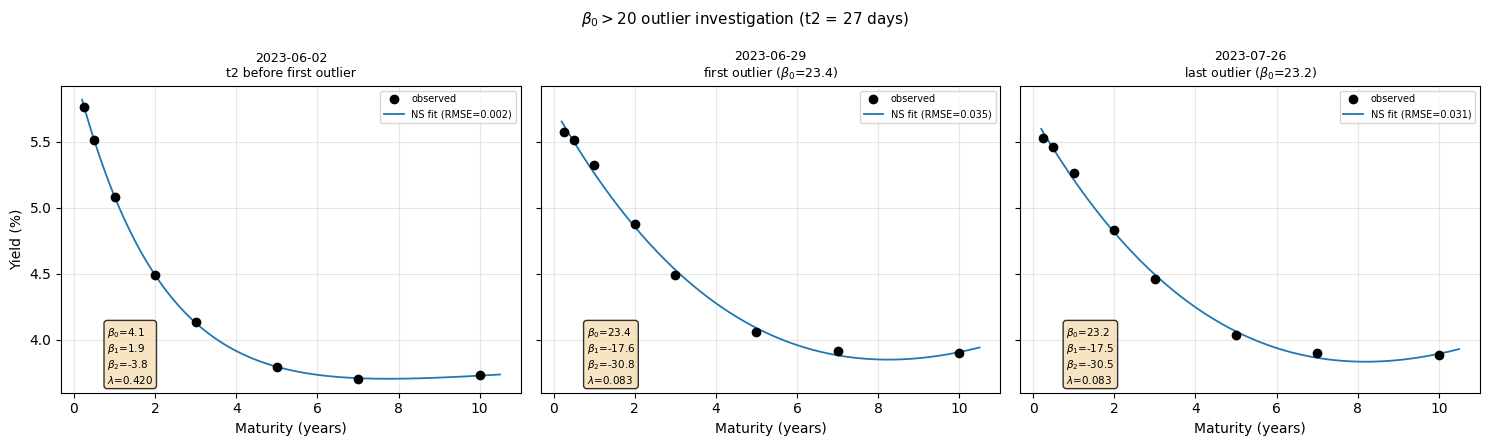

Outlier dates: 2023-06-29 and 2023-07-26 (t2 = 27 days)
Reference date (first - t2): 2023-06-02


In [ ]:
# Find the two most distant dates with beta0 > 20
outlier_mask = df_grid["beta0"] > 20
outliers = df_grid.loc[outlier_mask].sort_values("date")
first_out, last_out = outliers.iloc[0], outliers.iloc[-1]
t2 = last_out["date"] - first_out["date"]
third_date = first_out["date"] - t2

idx_third = nearest_idx(third_date)
idx_first = nearest_idx(first_out["date"])
idx_last  = nearest_idx(last_out["date"])

plot_info = [
    (idx_third, "t2 before first outlier"),
    (idx_first, f'first outlier ($\\beta_0$={first_out["beta0"]:.1f})'),
    (idx_last,  f'last outlier ($\\beta_0$={last_out["beta0"]:.1f})'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for k, (idx, subtitle) in enumerate(plot_info):
    ax = axes[k]
    rp, rg = panel.iloc[idx], df_grid.iloc[idx]
    y_obs = rp[tenor_cols].to_numpy(dtype=float)
    ax.plot(TENORS, y_obs, "ko", markersize=6, label="observed", zorder=5)
    ax.plot(T_fine, ns_curve(T_fine, rg["beta0"], rg["beta1"], rg["beta2"], rg["lam"]),
            "-", linewidth=1.3, color="C0", label=f'NS fit (RMSE={rg["rmse"]:.3f})')
    txt = (f'$\\beta_0$={rg["beta0"]:.1f}\n$\\beta_1$={rg["beta1"]:.1f}\n'
           f'$\\beta_2$={rg["beta2"]:.1f}\n$\\lambda$={rg["lam"]:.3f}')
    ax.text(0.1, 0.03, txt, transform=ax.transAxes, fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.8))
    ax.set_title(f"{rp['Date'].date()}\n{subtitle}", fontsize=9)
    ax.set_xlabel("Maturity (years)")
    ax.legend(fontsize=7, loc="upper right"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Yield (%)")
fig.suptitle(f"$\\beta_0 > 20$ outlier investigation (t2 = {t2.days} days)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_outliers.pdf"))
plt.show(); plt.close(fig)

print(f"Outlier dates: {first_out['date'].date()} and {last_out['date'].date()} "
      f"(t2 = {t2.days} days)")
print(f"Reference date (first - t2): {panel.iloc[idx_third]['Date'].date()}")

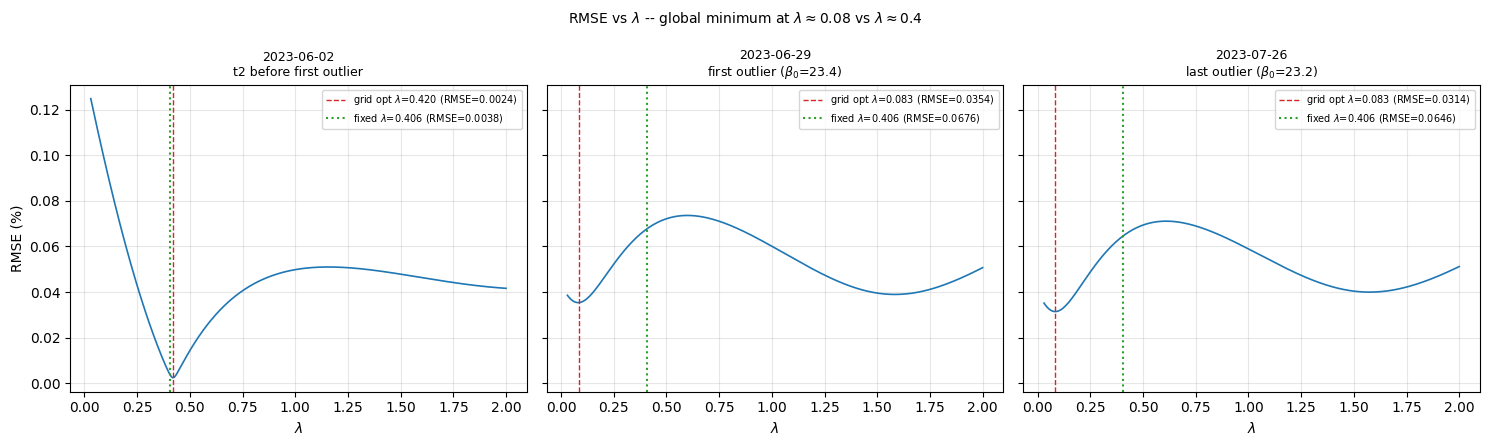

In [ ]:
# RMSE as a function of lambda for the three dates.
lam_scan = np.linspace(0.03, 2.0, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for k, (idx, subtitle) in enumerate(plot_info):
    ax = axes[k]
    rp, rg = panel.iloc[idx], df_grid.iloc[idx]
    y_obs = rp[tenor_cols].to_numpy(dtype=float)
    rmses = np.array([fit_ns_ols(y_obs, TENORS, l)[2] for l in lam_scan])
    ax.plot(lam_scan, rmses, "-", linewidth=1.2, color="C0")
    ax.axvline(rg["lam"], color="C3", linestyle="--", linewidth=1.0,
              label=f'grid opt $\\lambda$={rg["lam"]:.3f} (RMSE={rg["rmse"]:.4f})')
    _, _, rmse_fix, _ = fit_ns_ols(y_obs, TENORS, lam_fixed)
    ax.axvline(lam_fixed, color="C2", linestyle=":", linewidth=1.5,
              label=f'fixed $\\lambda$={lam_fixed:.3f} (RMSE={rmse_fix:.4f})')
    ax.set_title(f"{rp['Date'].date()}\n{subtitle}", fontsize=9)
    ax.set_xlabel(r"$\lambda$")
    ax.legend(fontsize=7, loc="upper right"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("RMSE (%)")
fig.suptitle("RMSE vs $\\lambda$ -- global minimum at $\\lambda \\approx 0.08$ "
             "vs $\\lambda \\approx 0.4$", fontsize=10)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_lambda_surface.pdf"))
plt.show(); plt.close(fig)

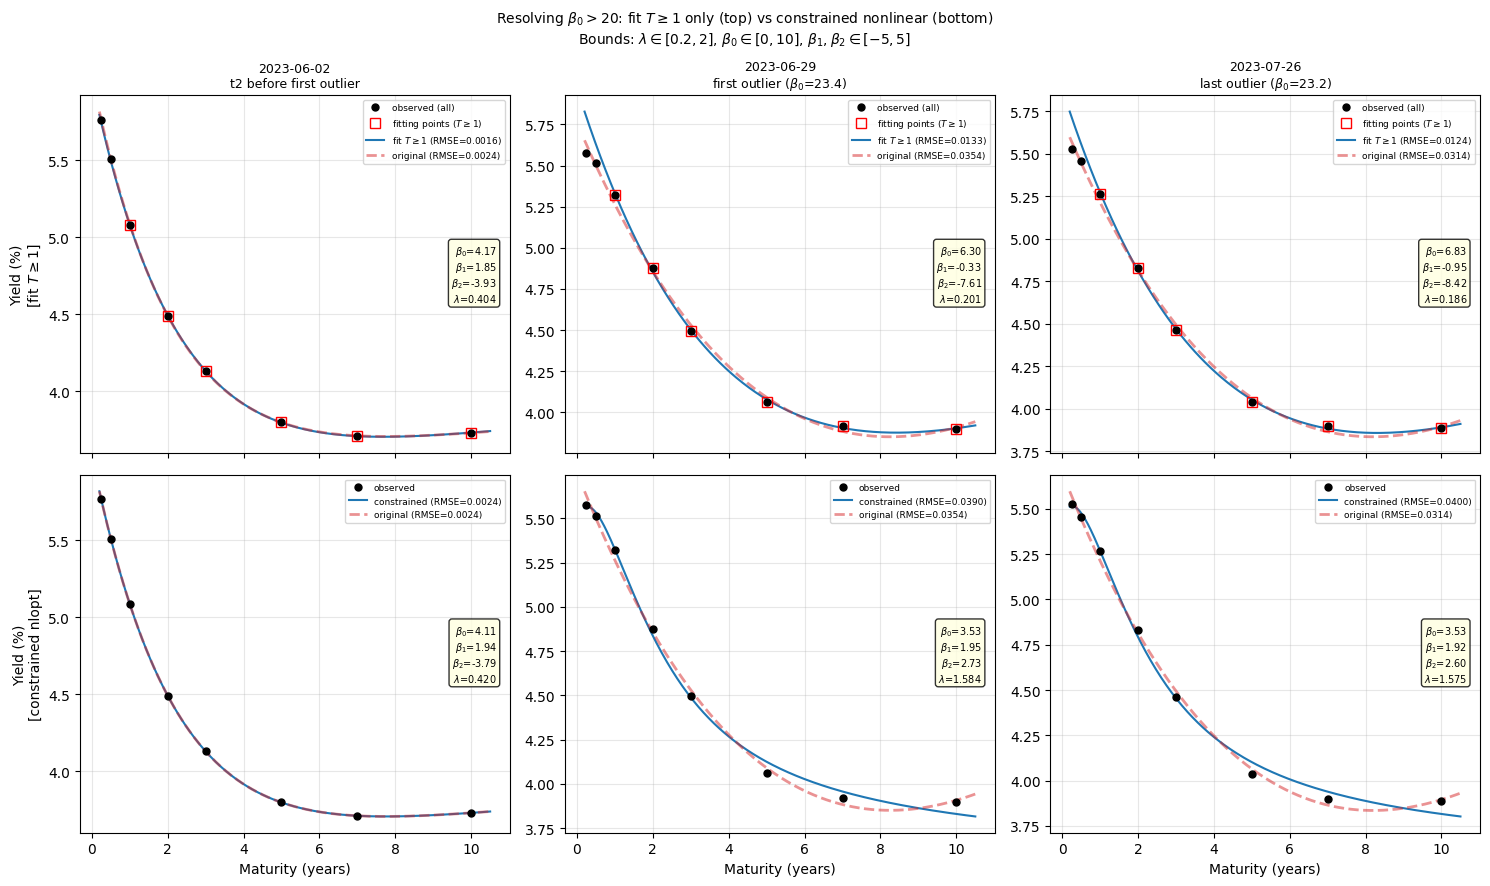

In [ ]:
# Two approaches to resolve beta0 > 20 instability:
# (1) fit only T >= 1Y; (2) constrained nonlinear on all tenors.

TENORS_GE1 = np.array([1, 2, 3, 5, 7, 10], dtype=float)
tenor_cols_ge1 = [f"Y_{t:g}" for t in TENORS_GE1]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
for k, (idx, subtitle) in enumerate(plot_info):
    rp, rg = panel.iloc[idx], df_grid.iloc[idx]
    y_all = rp[tenor_cols].to_numpy(dtype=float)
    y_ge1 = rp[tenor_cols_ge1].to_numpy(dtype=float)

    b1, _, r1, _, l1 = fit_ns_grid(y_ge1, TENORS_GE1, lam_grid)
    b2, _, r2, _, l2 = fit_ns_constrained(y_all, TENORS)
    yfit_orig = ns_curve(T_fine, rg["beta0"], rg["beta1"], rg["beta2"], rg["lam"])

    # Top: T >= 1
    ax = axes[0, k]
    ax.plot(TENORS, y_all, "ko", ms=5, label="observed (all)", zorder=5)
    ax.plot(TENORS_GE1, y_ge1, "rs", ms=7, mfc="none", lw=1.5,
            label="fitting points ($T \\geq 1$)", zorder=6)
    ax.plot(T_fine, ns_curve(T_fine, *b1, l1), "-", lw=1.5, color="C0",
            label=f"fit $T \\geq 1$ (RMSE={r1:.4f})")
    ax.plot(T_fine, yfit_orig, "--", lw=2, color="C3", alpha=0.5,
            label=f"original (RMSE={rg['rmse']:.4f})")
    txt = f"$\\beta_0$={b1[0]:.2f}\n$\\beta_1$={b1[1]:.2f}\n$\\beta_2$={b1[2]:.2f}\n$\\lambda$={l1:.3f}"
    ax.text(0.97, 0.5, txt, transform=ax.transAxes, fontsize=7,
            va="center", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
    ax.set_title(f"{rp['Date'].date()}\n{subtitle}", fontsize=9)
    ax.legend(fontsize=6.5, loc="upper right"); ax.grid(True, alpha=0.3)
    if k == 0: ax.set_ylabel("Yield (%)\n[fit $T \\geq 1$]")

    # Bottom: constrained
    ax = axes[1, k]
    ax.plot(TENORS, y_all, "ko", ms=5, label="observed", zorder=5)
    ax.plot(T_fine, ns_curve(T_fine, *b2, l2), "-", lw=1.5, color="C0",
            label=f"constrained (RMSE={r2:.4f})")
    ax.plot(T_fine, yfit_orig, "--", lw=2, color="C3", alpha=0.5,
            label=f"original (RMSE={rg['rmse']:.4f})")
    txt = f"$\\beta_0$={b2[0]:.2f}\n$\\beta_1$={b2[1]:.2f}\n$\\beta_2$={b2[2]:.2f}\n$\\lambda$={l2:.3f}"
    ax.text(0.97, 0.5, txt, transform=ax.transAxes, fontsize=7,
            va="center", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
    ax.set_xlabel("Maturity (years)")
    ax.legend(fontsize=6.5, loc="upper right"); ax.grid(True, alpha=0.3)
    if k == 0: ax.set_ylabel("Yield (%)\n[constrained nlopt]")

fig.suptitle("Resolving $\\beta_0 > 20$: fit $T \\geq 1$ only (top) "
             "vs constrained nonlinear (bottom)\n"
             "Bounds: $\\lambda \\in [0.2, 2]$, $\\beta_0 \\in [0, 10]$, "
             "$\\beta_1, \\beta_2 \\in [-5, 5]$", fontsize=10)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_outlier_fixes.pdf"))
plt.show(); plt.close(fig)

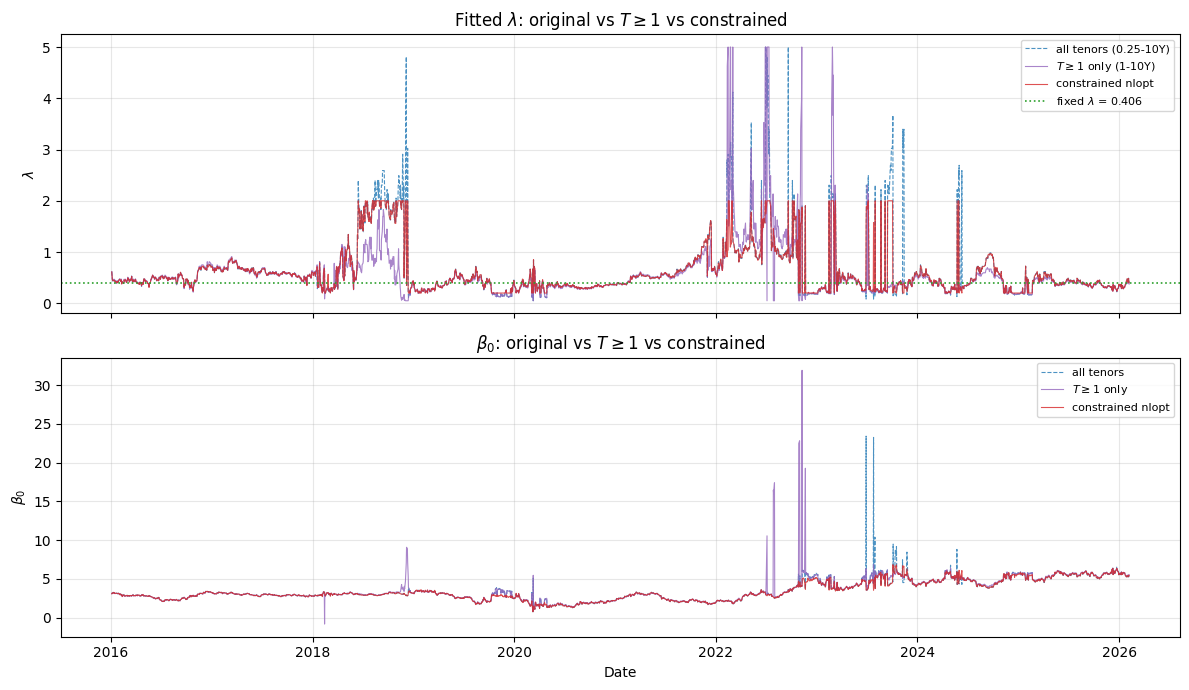

T>=1: max beta0 = 31.90 (vs 23.40 with all tenors)
Constrained: max beta0 = 6.82, lambda range [0.200, 2.000]


In [ ]:
# Fitted lambda and beta0 over time: original vs T >= 1 vs constrained.
Y_mat_ge1 = panel[tenor_cols_ge1].to_numpy(dtype=float)
grid_lam_ge1  = np.empty(N)
grid_b0_ge1   = np.empty(N)
constr_lam    = np.empty(N)
constr_b0     = np.empty(N)
for i in range(N):
    bg, _, _, _, lg = fit_ns_grid(Y_mat_ge1[i], TENORS_GE1, lam_grid)
    grid_lam_ge1[i] = lg
    grid_b0_ge1[i]  = bg[0]
    bc, _, _, _, lc = fit_ns_constrained(Y_mat[i], TENORS)
    constr_lam[i] = lc
    constr_b0[i]  = bc[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(dates, df_grid["lam"], "--", lw=0.8, color="C0",
        label="all tenors (0.25-10Y)", alpha=0.8)
ax.plot(dates, grid_lam_ge1, "-", lw=0.8, color="C4",
        label="$T \\geq 1$ only (1-10Y)", alpha=0.8)
ax.plot(dates, constr_lam, "-", lw=0.8, color="C3",
        label="constrained nlopt", alpha=0.8)
ax.axhline(lam_fixed, color="C2", linestyle=":", lw=1.2,
           label=f"fixed $\\lambda$ = {lam_fixed:.3f}")
ax.set_ylabel(r"$\lambda$")
ax.set_title("Fitted $\\lambda$: original vs $T \\geq 1$ vs constrained")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(dates, df_grid["beta0"], "--", lw=0.8, color="C0",
        label="all tenors", alpha=0.8)
ax.plot(dates, grid_b0_ge1, "-", lw=0.8, color="C4",
        label="$T \\geq 1$ only", alpha=0.8)
ax.plot(dates, constr_b0, "-", lw=0.8, color="C3",
        label="constrained nlopt", alpha=0.8)
ax.set_ylabel(r"$\beta_0$"); ax.set_xlabel("Date")
ax.set_title("$\\beta_0$: original vs $T \\geq 1$ vs constrained")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/gsw_outlier_fixes_lambda_beta0.pdf"))
plt.show(); plt.close(fig)

print(f"T>=1: max beta0 = {grid_b0_ge1.max():.2f} "
      f"(vs {df_grid['beta0'].max():.2f} with all tenors)")
print(f"Constrained: max beta0 = {constr_b0.max():.2f}, "
      f"lambda range [{constr_lam.min():.3f}, {constr_lam.max():.3f}]")

# Part (D) - Dynamic Nelson-Siegel (DNS)

## Motivation

In Part C we fitted the Nelson-Siegel model to each day independently. This gives us a time series of factors $(\beta_{0,t}, \beta_{1,t}, \beta_{2,t})$, but each day's estimate knows nothing about yesterday's. As we saw in C(iv), this can produce wild parameter jumps between consecutive days even when the yield curve barely moved.

The assignment offers two extensions: (D1) Dynamic NS with a Kalman filter, and (D2) Nelson-Siegel-Svensson with an extra curvature term. The GSW dataset already provides Svensson parameters $(\beta_0, \ldots, \beta_3, \tau_1, \tau_2)$ for every day, so fitting NSS cross-sectionally would essentially re-derive what the Fed already publishes. Moreover, adding parameters without clear purpose, just to improve the fit, does not match the philosophy of a physicist. We therefore choose **D1**: take the NS factors from Part C and model their dynamics over time using a state-space approach with the Kalman filter.

The Dynamic Nelson-Siegel model was introduced by Diebold and Li (2006), who showed that treating the NS factors as latent states evolving under a vector autoregression, and estimating them via the Kalman filter, produces both smoother factor paths and better out-of-sample forecasts than fitting each day independently.

## The two-equation structure

A state-space model consists of two equations.

### 1. State equation (how the factors evolve day to day)

$$
\underbrace{\mathbf{X}_t}_{3 \times 1\text{ today's factors}}
= \underbrace{\mathbf{c}}_{3 \times 1}
+ \underbrace{\boldsymbol{\Phi}}_{3 \times 3}
\,\underbrace{\mathbf{X}_{t-1}}_{3 \times 1\text{ yesterday's factors}}
+ \boldsymbol{\eta}_t,
\qquad \boldsymbol{\eta}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{Q})
$$

where $\mathbf{X}_t = (\beta_{0,t},\, \beta_{1,t},\, \beta_{2,t})^\top$ is the vector of NS factors (the **state** we want to estimate), $\mathbf{c}$ is a $3 \times 1$ intercept, and $\boldsymbol{\Phi}$ is a $3 \times 3$ **transition matrix**.

This is a **VAR(1)** --- a Vector AutoRegression of order 1. "Vector" because 3 variables evolve jointly; "order 1" because only yesterday's values appear (no $t{-}2$, $t{-}3$, etc.). The off-diagonal entries of $\boldsymbol{\Phi}$ capture cross-factor dynamics.

**How we estimate $\mathbf{c}$ and $\boldsymbol{\Phi}$:** The state equation is simply a multivariate linear regression of today's factors on yesterday's. We take the $N \approx 2{,}524$ daily OLS factor estimates from Part C, form the regressor matrix $\mathbf{Z} = [\mathbf{1},\; \mathbf{X}_{t-1}]$ (an $(N{-}1) \times 4$ matrix: a column of ones plus 3 lagged factors), and solve
$$
\begin{pmatrix} \mathbf{c}^\top \\ \boldsymbol{\Phi}^\top \end{pmatrix}
= (\mathbf{Z}^\top \mathbf{Z})^{-1}\, \mathbf{Z}^\top \mathbf{X}_{\mathrm{cur}}
$$
where $\mathbf{X}_{\mathrm{cur}}$ stacks all the "today" vectors. The first row of the $4 \times 3$ result gives $\mathbf{c}$ (3 intercepts), and rows 2--4 give $\boldsymbol{\Phi}^\top$ (transposed to get $3 \times 3$). The residual covariance gives $\mathbf{Q}$.

### 2. Measurement equation (how observed yields relate to factors)

$$
\underbrace{\mathbf{Y}_t}_{8 \times 1\text{ observed yields}}
= \underbrace{\boldsymbol{\Lambda}}_{8 \times 3\text{ NS loadings}}
\,\underbrace{\mathbf{X}_t}_{3 \times 1\text{ factors}}
+ \boldsymbol{\varepsilon}_t,
\qquad \boldsymbol{\varepsilon}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{R})
$$

Here $\mathbf{Y}_t$ is the 8-vector of observed yields, $\mathbf{X}_t$ is the 3-vector of latent factors (the same as in the state equation), and $\boldsymbol{\Lambda}$ is the $8 \times 3$ matrix of NS loadings. Its $i$-th row is:

$$
\boldsymbol{\Lambda}_i = \begin{pmatrix}
1 & \frac{1-e^{-\lambda T_i}}{\lambda T_i}
& \frac{1-e^{-\lambda T_i}}{\lambda T_i} - e^{-\lambda T_i}
\end{pmatrix}
$$

$\boldsymbol{\Lambda}$ is the same design matrix we used in Part C's OLS. Because we **fix $\lambda$** at the value chosen by cross-validation in Part C (the "CV-optimal" $\lambda \approx 0.41$, i.e. the value that minimized the median RMSE across all days when we scanned 200 candidates), $\boldsymbol{\Lambda}$ is a **known constant** --- the same matrix every day. This is what makes the standard (linear) Kalman filter applicable.

$\mathbf{R} = \sigma^2_\varepsilon \mathbf{I}_8$ is the measurement noise covariance. We estimate $\sigma_\varepsilon$ from the median daily OLS RMSE.

## The Kalman filter

The filter never observes the factors directly. It infers them by combining two pieces of information at each time step:

**Predict** (use the VAR to forecast from yesterday):
$$
\hat{\mathbf{X}}_{t|t-1} = \mathbf{c} + \boldsymbol{\Phi}\,\hat{\mathbf{X}}_{t-1|t-1},
\qquad
\mathbf{P}_{t|t-1} = \boldsymbol{\Phi}\,\mathbf{P}_{t-1|t-1}\,\boldsymbol{\Phi}^\top + \mathbf{Q}
$$

Here $\hat{\mathbf{X}}_{t|t-1}$ is the predicted state and $\mathbf{P}_{t|t-1}$ is its $3 \times 3$ **uncertainty covariance**: how confident we are in the prediction. The predict step *increases* uncertainty (adds $\mathbf{Q}$).

**Update** (incorporate today's 8 observed yields):
$$
\mathbf{v}_t = \mathbf{Y}_t - \boldsymbol{\Lambda}\,\hat{\mathbf{X}}_{t|t-1}
\qquad \text{(innovation: observed minus predicted yields)}
$$
$$
\mathbf{K}_t = \mathbf{P}_{t|t-1}\,\boldsymbol{\Lambda}^\top
\bigl(\boldsymbol{\Lambda}\,\mathbf{P}_{t|t-1}\,\boldsymbol{\Lambda}^\top + \mathbf{R}\bigr)^{-1}
\qquad \text{(Kalman gain: }3 \times 8\text{ matrix)}
$$
$$
\hat{\mathbf{X}}_{t|t} = \hat{\mathbf{X}}_{t|t-1} + \mathbf{K}_t\,\mathbf{v}_t,
\qquad
\mathbf{P}_{t|t} = (\mathbf{I}_3 - \mathbf{K}_t\,\boldsymbol{\Lambda})\,\mathbf{P}_{t|t-1}
$$

The **Kalman gain** $\mathbf{K}_t$ is the key quantity. It controls how much to correct the prediction using the innovation:

- If $\mathbf{P}$ is large (uncertain prediction) $\Rightarrow$ $\mathbf{K}$ is large $\Rightarrow$ trust the new data, adjust strongly.
- If $\mathbf{R}$ is large (noisy yields) $\Rightarrow$ $\mathbf{K}$ is small $\Rightarrow$ trust the prediction, ignore the data.

The update step *decreases* uncertainty: $\mathbf{P}_{t|t} < \mathbf{P}_{t|t-1}$ (in the matrix sense) --- we learned something from the data.

**Why this resolves $\beta_0 > 20$:** On those outlier days, two parameter sets fit the curve nearly equally well. The Kalman prediction says "$\beta_0$ should be around 4--5" with high confidence. The crazy solution ($\beta_0 \approx 23$) would produce a huge innovation $\mathbf{v}_t$, so the filter ignores it and stays near the sensible value. No ad-hoc constraints needed.

## Implementation plan

1. Fix $\lambda$ at the CV-optimal value from Part C.
2. Estimate $(\mathbf{c}, \boldsymbol{\Phi}, \mathbf{Q})$ by OLS regression of $\mathbf{X}_t$ on $\mathbf{X}_{t-1}$.
3. Estimate $\sigma^2_\varepsilon$ from the median OLS fitting residual.
4. Run the Kalman filter and RTS smoother.
5. Compare filtered factors to the daily OLS and nonlinear fits.
6. Evaluate out-of-sample via rolling-window 1-day-ahead forecasts.

In [ ]:
# ── Step 1: Fix lambda, build the loadings matrix ──
# lam_fixed and tenor_cols are already defined from Part C.

A1_lam, A2_lam = ns_loadings(TENORS, lam_fixed)
Lambda = np.column_stack([np.ones(len(TENORS)), A1_lam, A2_lam])  # (8 x 3)
print(f"Measurement matrix Lambda: {Lambda.shape}")
print(f"Fixed lambda = {lam_fixed:.4f}")

# ── Step 2: Estimate VAR(1) from OLS factors ──
# Use the grid-search factors from Part C as initial two-step estimates.
X_ols = df_grid[["beta0", "beta1", "beta2"]].to_numpy()  # (N x 3)

# VAR(1): X_t = c + Phi * X_{t-1} + eta_t
# Estimate by multivariate OLS: regress X[1:] on [1, X[:-1]]
X_cur  = X_ols[1:]    # (N-1 x 3)
X_prev = X_ols[:-1]   # (N-1 x 3)
Z = np.column_stack([np.ones(len(X_prev)), X_prev])  # (N-1 x 4)

# OLS: [c, Phi^T]^T = (Z'Z)^{-1} Z' X_cur
coeffs = npl.lstsq(Z, X_cur, rcond=None)[0]  # (4 x 3)
c_var = coeffs[0]          # (3,) intercept
Phi   = coeffs[1:].T       # (3 x 3) transition matrix

# Residuals and state noise covariance Q
eta = X_cur - Z @ coeffs   # (N-1 x 3)
Q = (eta.T @ eta) / (len(eta) - 4)  # (3 x 3), bias-corrected

print("\nVAR(1) intercept c:")
print(f"  {c_var.round(4)}")
print("\nTransition matrix Phi:")
for row in Phi:
    print("  [" + "  ".join(f"{v:8.4f}" for v in row) + "]")
print(f"\nPhi eigenvalues: {npl.eigvals(Phi).round(4)}")
print("  (all < 1 in modulus => stationary VAR)")

# ── Step 3: Measurement noise variance ──
# Use median daily RMSE^2 from OLS fits (in percent^2)
sigma2_eps = float(np.median(df_grid["rmse"])**2)
R = sigma2_eps * np.eye(len(TENORS))  # (8 x 8)
print(f"\nMeasurement noise: sigma_eps = {np.sqrt(sigma2_eps):.4f}% "
      f"(median OLS RMSE)")

Measurement matrix Lambda: (8, 3)
Fixed lambda = 0.4058

VAR(1) intercept c:
  [ 0.9248 -0.9374 -1.4811]

Transition matrix Phi:
  [  0.8421    0.2344    0.0625]
  [  0.1780    0.7425   -0.0207]
  [  0.1991   -0.3483    0.7880]

Phi eigenvalues: [0.5085 0.9958 0.8683]
  (all < 1 in modulus => stationary VAR)

Measurement noise: sigma_eps = 0.0016% (median OLS RMSE)


In [ ]:
# ── Step 4: Kalman filter ──

def kalman_filter(Y, Lambda, c, Phi, Q, R):
    """Forward Kalman filter.
    Y:      (T x n_obs) observed yields
    Lambda: (n_obs x n_state) measurement matrix
    c:      (n_state,) state intercept
    Phi:    (n_state x n_state) transition matrix
    Q:      (n_state x n_state) state noise covariance
    R:      (n_obs x n_obs) measurement noise covariance
    Returns: X_filt, P_filt, X_pred, P_pred, log_lik
    """
    T, n_obs = Y.shape
    n = Phi.shape[0]

    X_filt = np.zeros((T, n))      # filtered states
    P_filt = np.zeros((T, n, n))   # filtered covariances
    X_pred = np.zeros((T, n))      # predicted states
    P_pred = np.zeros((T, n, n))   # predicted covariances
    log_lik = 0.0

    # Initialize at unconditional mean and covariance of VAR(1)
    # Solve: X_ss = (I - Phi)^{-1} c
    # Solve: vec(P_ss) = (I - Phi kron Phi)^{-1} vec(Q)
    I_n = np.eye(n)
    X0 = npl.solve(I_n - Phi, c)
    P0 = npl.solve(np.eye(n**2) - np.kron(Phi, Phi), Q.flatten()).reshape(n, n)

    x_prev, P_prev = X0, P0

    for t in range(T):
        # Predict
        x_p = c + Phi @ x_prev
        P_p = Phi @ P_prev @ Phi.T + Q
        X_pred[t] = x_p
        P_pred[t] = P_p

        # Innovation
        v = Y[t] - Lambda @ x_p
        S = Lambda @ P_p @ Lambda.T + R  # innovation covariance

        # Kalman gain
        K = P_p @ Lambda.T @ npl.inv(S)

        # Update
        x_f = x_p + K @ v
        P_f = (I_n - K @ Lambda) @ P_p
        X_filt[t] = x_f
        P_filt[t] = P_f

        # Log-likelihood contribution
        log_lik += -0.5 * (n_obs * np.log(2*np.pi)
                           + np.log(npl.det(S))
                           + v @ npl.solve(S, v))

        x_prev, P_prev = x_f, P_f

    return X_filt, P_filt, X_pred, P_pred, log_lik


# Run
X_f, P_f, X_p, P_p, ll = kalman_filter(Y_mat, Lambda, c_var, Phi, Q, R)

print(f"Kalman filter log-likelihood: {ll:.1f}")
print(f"Filtered factors shape: {X_f.shape}")

Kalman filter log-likelihood: -7245696.1
Filtered factors shape: (2524, 3)


## D(i) - Filtered factors vs OLS and nonlinear estimates

We compare the Kalman-filtered factor paths with the daily OLS (grid-search) and nonlinear optimization estimates from Part C.

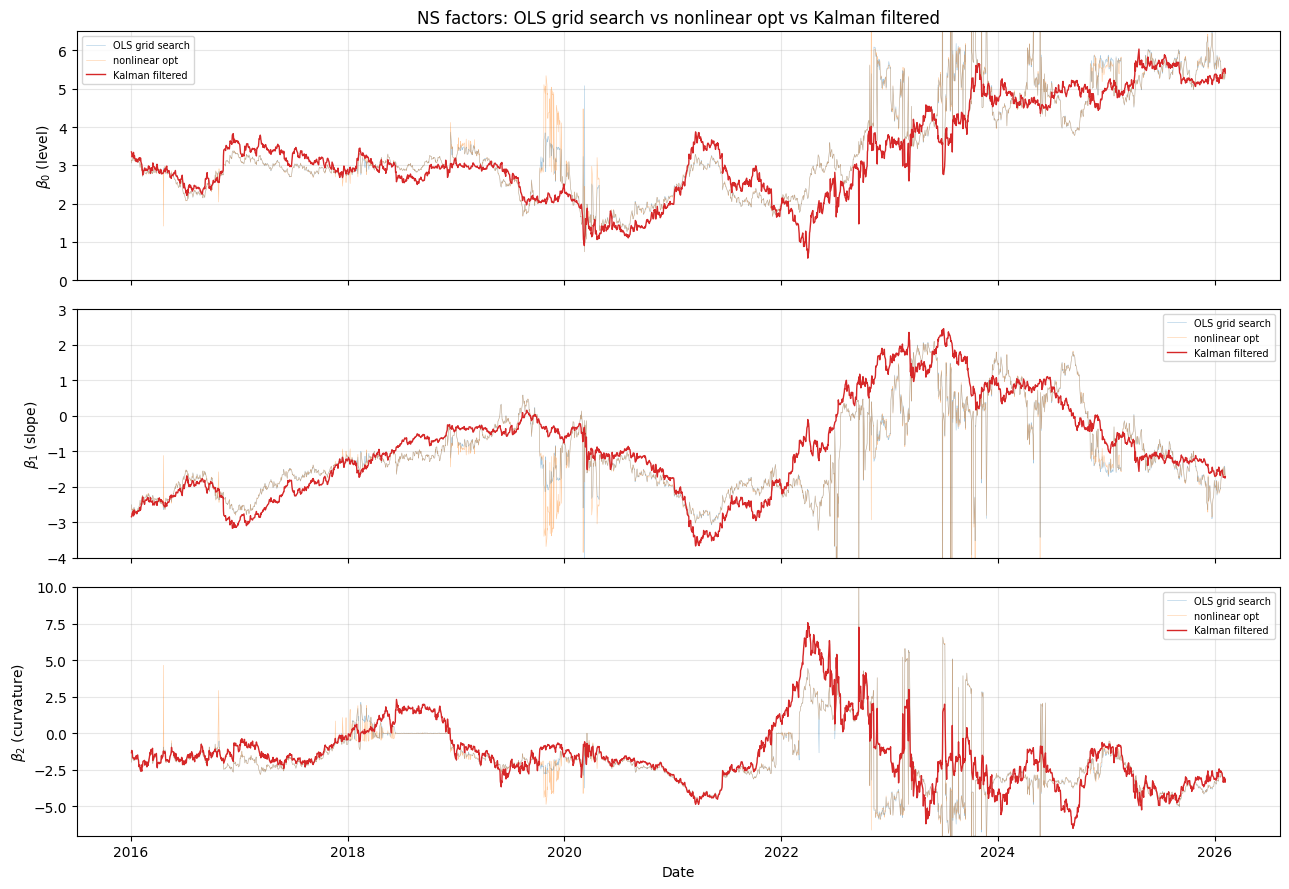

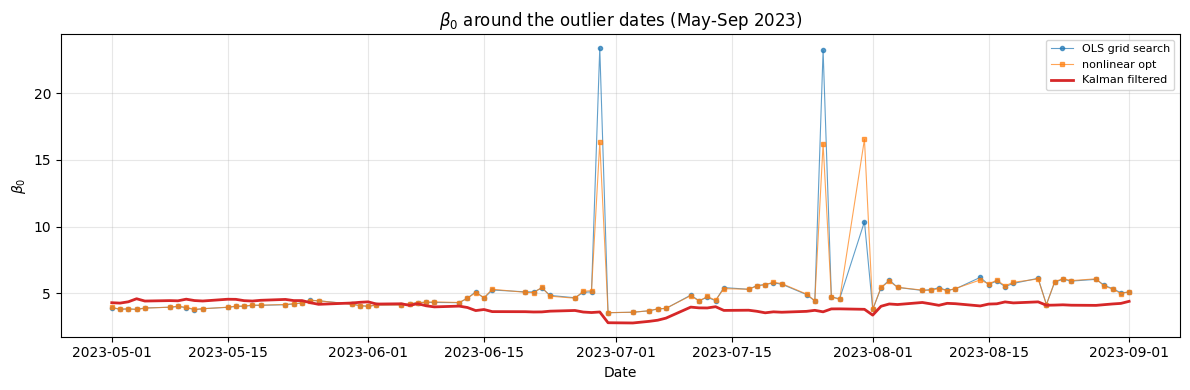

OLS grid  beta0 range: [0.74, 23.40]
Nlopt     beta0 range: [0.74, 16.55]
Filtered  beta0 range: [0.57, 6.04]


In [ ]:
# Factor comparison: OLS (grid) vs nonlinear opt vs Kalman filtered
X_nlopt = df_nlopt[["beta0", "beta1", "beta2"]].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
labels = [r"$\beta_0$ (level)", r"$\beta_1$ (slope)", r"$\beta_2$ (curvature)"]

ranges = {
        "beta0": (0, 6.5),
        "beta1": (-4, 3),
        "beta2": (-7, 10),
}

for j in range(3):
    ax = axes[j]
    ax.set_ylim(*ranges.get(f"beta{j}", None))
    ax.plot(dates, X_ols[:, j], linewidth=0.4, alpha=0.4, color="C0",
            label="OLS grid search")
    ax.plot(dates, X_nlopt[:, j], linewidth=0.4, alpha=0.4, color="C1",
            label="nonlinear opt")
    ax.plot(dates, X_f[:, j], linewidth=1.0, color="C3",
            label="Kalman filtered")
    ax.set_ylabel(labels[j])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_title("NS factors: OLS grid search vs nonlinear opt vs Kalman filtered")
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.savefig(os.path.join("report/output/kalman_factors.pdf"))
plt.show(); plt.close(fig)

# Zoom into the beta0 > 20 outlier region
fig, ax = plt.subplots(figsize=(12, 4))
mask = (dates >= np.datetime64("2023-05-01")) & (dates <= np.datetime64("2023-09-01"))
ax.plot(dates[mask], X_ols[mask, 0], "o-", ms=3, lw=0.8, color="C0",
        label="OLS grid search", alpha=0.7)
ax.plot(dates[mask], X_nlopt[mask, 0], "s-", ms=3, lw=0.8, color="C1",
        label="nonlinear opt", alpha=0.7)
ax.plot(dates[mask], X_f[mask, 0], "-", lw=2, color="C3",
        label="Kalman filtered")
ax.set_ylabel(r"$\beta_0$"); ax.set_xlabel("Date")
ax.set_title("$\\beta_0$ around the outlier dates (May-Sep 2023)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/kalman_beta0_zoom.pdf"))
plt.show(); plt.close(fig)

print(f"OLS grid  beta0 range: [{X_ols[:,0].min():.2f}, {X_ols[:,0].max():.2f}]")
print(f"Nlopt     beta0 range: [{X_nlopt[:,0].min():.2f}, {X_nlopt[:,0].max():.2f}]")
print(f"Filtered  beta0 range: [{X_f[:,0].min():.2f}, {X_f[:,0].max():.2f}]")

## D(ii) - In-sample yield fit: OLS vs nonlinear vs Kalman

We compare how well each set of factors reproduces the observed yields. All three methods use the same fixed $\lambda$, so the comparison is apples-to-apples.

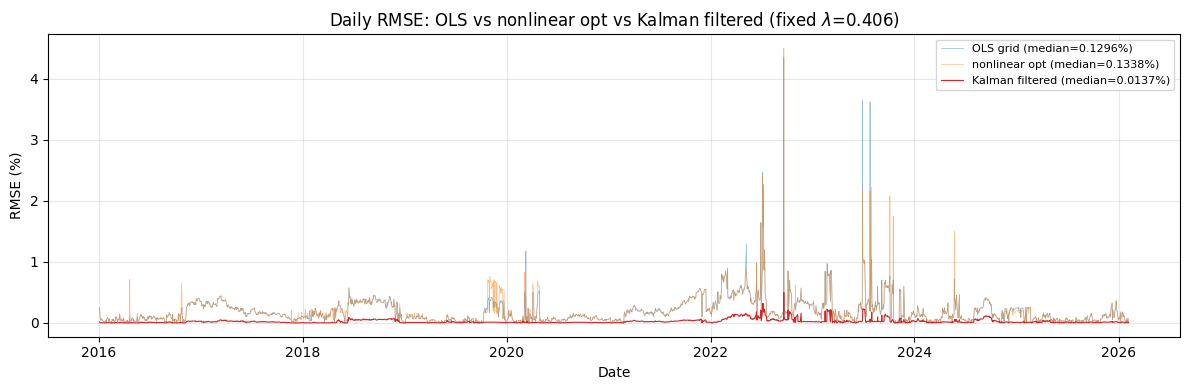

RMSE summary (all with fixed lambda):
  OLS grid:     median=0.1296%, mean=0.1903%, max=4.3532%
  Nonlinear:    median=0.1338%, mean=0.1950%, max=4.5065%
  Filtered:     median=0.0137%, mean=0.0261%, max=0.5009%


In [ ]:
# Compute fitted yields and RMSE for each method (all using fixed lambda)
Yhat_ols    = X_ols   @ Lambda.T    # (N x 8)
Yhat_nlopt  = X_nlopt @ Lambda.T
Yhat_filt   = X_f     @ Lambda.T

rmse_ols_d    = np.sqrt(np.mean((Y_mat - Yhat_ols)**2, axis=1))
rmse_nlopt_d  = np.sqrt(np.mean((Y_mat - Yhat_nlopt)**2, axis=1))
rmse_filt_d   = np.sqrt(np.mean((Y_mat - Yhat_filt)**2, axis=1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, rmse_ols_d, linewidth=0.5, alpha=0.5, color="C0",
        label=f"OLS grid (median={np.median(rmse_ols_d):.4f}%)")
ax.plot(dates, rmse_nlopt_d, linewidth=0.5, alpha=0.5, color="C1",
        label=f"nonlinear opt (median={np.median(rmse_nlopt_d):.4f}%)")
ax.plot(dates, rmse_filt_d, linewidth=0.8, color="C3",
        label=f"Kalman filtered (median={np.median(rmse_filt_d):.4f}%)")
ax.set_ylabel("RMSE (%)"); ax.set_xlabel("Date")
ax.set_title("Daily RMSE: OLS vs nonlinear opt vs Kalman filtered "
             f"(fixed $\\lambda$={lam_fixed:.3f})")
ax.legend(fontsize=8)
plt.savefig(os.path.join("report/output/kalman_rmse_time.pdf"))
ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show(); plt.close(fig)

# Note: for a fair comparison, the OLS and nlopt RMSE here are
# recomputed with fixed lambda (not their own optimal lambda).
# The grid-search and nlopt fits used day-specific lambda, so their
# Part C RMSE was lower. Here we isolate the effect of the Kalman filter.
print("RMSE summary (all with fixed lambda):")
print(f"  OLS grid:     median={np.median(rmse_ols_d):.4f}%, "
      f"mean={np.mean(rmse_ols_d):.4f}%, max={np.max(rmse_ols_d):.4f}%")
print(f"  Nonlinear:    median={np.median(rmse_nlopt_d):.4f}%, "
      f"mean={np.mean(rmse_nlopt_d):.4f}%, max={np.max(rmse_nlopt_d):.4f}%")
print(f"  Filtered:     median={np.median(rmse_filt_d):.4f}%, "
      f"mean={np.mean(rmse_filt_d):.4f}%, max={np.max(rmse_filt_d):.4f}%")

## D(iii) - Out-of-sample evaluation (rolling window)

We evaluate the DNS model's predictive accuracy using a rolling window: at each day $t$, we estimate the VAR(1) on data up to $t{-}1$, run the Kalman filter forward to produce the 1-day-ahead prediction $\hat{\mathbf{X}}_{t|t-1}$, and compute the predicted yield curve. This is a genuine out-of-sample test.

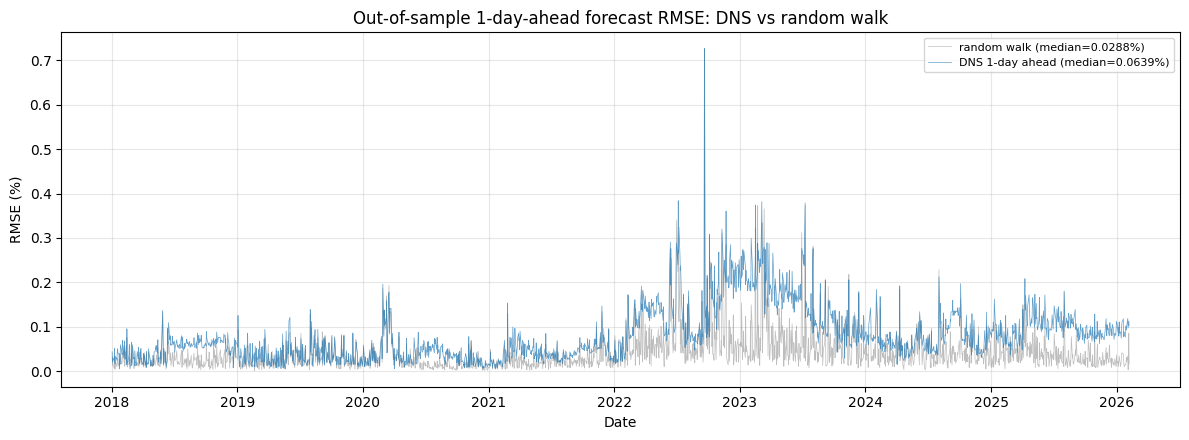

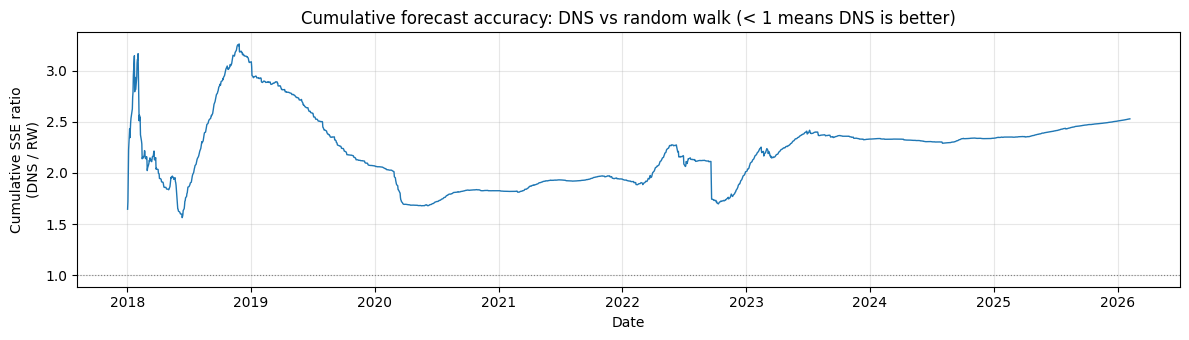

OOS period: 2018-01-02 to 2026-02-06 (2024 days)
DNS median RMSE: 0.0639%
RW  median RMSE: 0.0288%
Final cumulative SSE ratio (DNS/RW): 2.5281


In [ ]:
# Rolling out-of-sample 1-day-ahead forecast
BURN_IN = 500
n_oos = N - BURN_IN

oos_rmse_kf = np.full(n_oos, np.nan)
oos_rmse_rw = np.full(n_oos, np.nan)

c_cur, Phi_cur, Q_cur = c_var.copy(), Phi.copy(), Q.copy()
x_cur = X_f[BURN_IN - 1].copy()
P_cur = P_f[BURN_IN - 1].copy()

for i in range(n_oos):
    t = BURN_IN + i
    if i % 60 == 0:
        Xo = X_ols[:t]
        Zz = np.column_stack([np.ones(len(Xo)-1), Xo[:-1]])
        cc = npl.lstsq(Zz, Xo[1:], rcond=None)[0]
        c_cur = cc[0]; Phi_cur = cc[1:].T
        ee = Xo[1:] - Zz @ cc
        Q_cur = (ee.T @ ee) / (len(ee) - 4)
    x_pred = c_cur + Phi_cur @ x_cur
    P_pred = Phi_cur @ P_cur @ Phi_cur.T + Q_cur
    y_pred_kf = Lambda @ x_pred
    oos_rmse_kf[i] = np.sqrt(np.mean((Y_mat[t] - y_pred_kf)**2))
    oos_rmse_rw[i] = np.sqrt(np.mean((Y_mat[t] - Y_mat[t-1])**2))
    v = Y_mat[t] - Lambda @ x_pred
    S = Lambda @ P_pred @ Lambda.T + R
    K = P_pred @ Lambda.T @ npl.inv(S)
    x_cur = x_pred + K @ v
    P_cur = (np.eye(3) - K @ Lambda) @ P_pred

oos_dates = dates[BURN_IN:]

# Plot 1: daily OOS RMSE
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(oos_dates, oos_rmse_rw, linewidth=0.5, alpha=0.5, color="C7",
        label=f"random walk (median={np.nanmedian(oos_rmse_rw):.4f}%)")
ax.plot(oos_dates, oos_rmse_kf, linewidth=0.5, alpha=0.7, color="C0",
        label=f"DNS 1-day ahead (median={np.nanmedian(oos_rmse_kf):.4f}%)")
ax.set_ylabel("RMSE (%)"); ax.set_xlabel("Date")
ax.set_title("Out-of-sample 1-day-ahead forecast RMSE: DNS vs random walk")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/kalman_oos_rmse.pdf"))
plt.show(); plt.close(fig)

# Plot 2: cumulative SSE ratio
cum_sse_kf = np.nancumsum(oos_rmse_kf**2)
cum_sse_rw = np.nancumsum(oos_rmse_rw**2)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(oos_dates, cum_sse_kf / cum_sse_rw, linewidth=1, color="C0")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
ax.set_ylabel("Cumulative SSE ratio\n(DNS / RW)")
ax.set_xlabel("Date")
ax.set_title("Cumulative forecast accuracy: DNS vs random walk (< 1 means DNS is better)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join("report/output/kalman_oos_cumsse.pdf"))
plt.show(); plt.close(fig)

print(f"OOS period: {oos_dates[0].astype('datetime64[D]')} to "
      f"{oos_dates[-1].astype('datetime64[D]')} ({n_oos} days)")
print(f"DNS median RMSE: {np.nanmedian(oos_rmse_kf):.4f}%")
print(f"RW  median RMSE: {np.nanmedian(oos_rmse_rw):.4f}%")
print(f"Final cumulative SSE ratio (DNS/RW): "
      f"{cum_sse_kf[-1]/cum_sse_rw[-1]:.4f}")

## D(iv) - VAR(1) diagnostics

We examine the estimated VAR dynamics: eigenvalues of $\boldsymbol{\Phi}$ (persistence), impulse responses, and the unconditional factor means.

Phi eigenvalues (modulus):
  0.5085  (|.|=0.5085, half-life=1.0 days)
  0.9958  (|.|=0.9958, half-life=165.7 days)
  0.8683  (|.|=0.8683, half-life=4.9 days)

Unconditional mean of factors:
  beta0 = 3.620 (long-run yield level)
  beta1 = -0.980 (long-run slope)
  beta2 = -1.976 (long-run curvature)


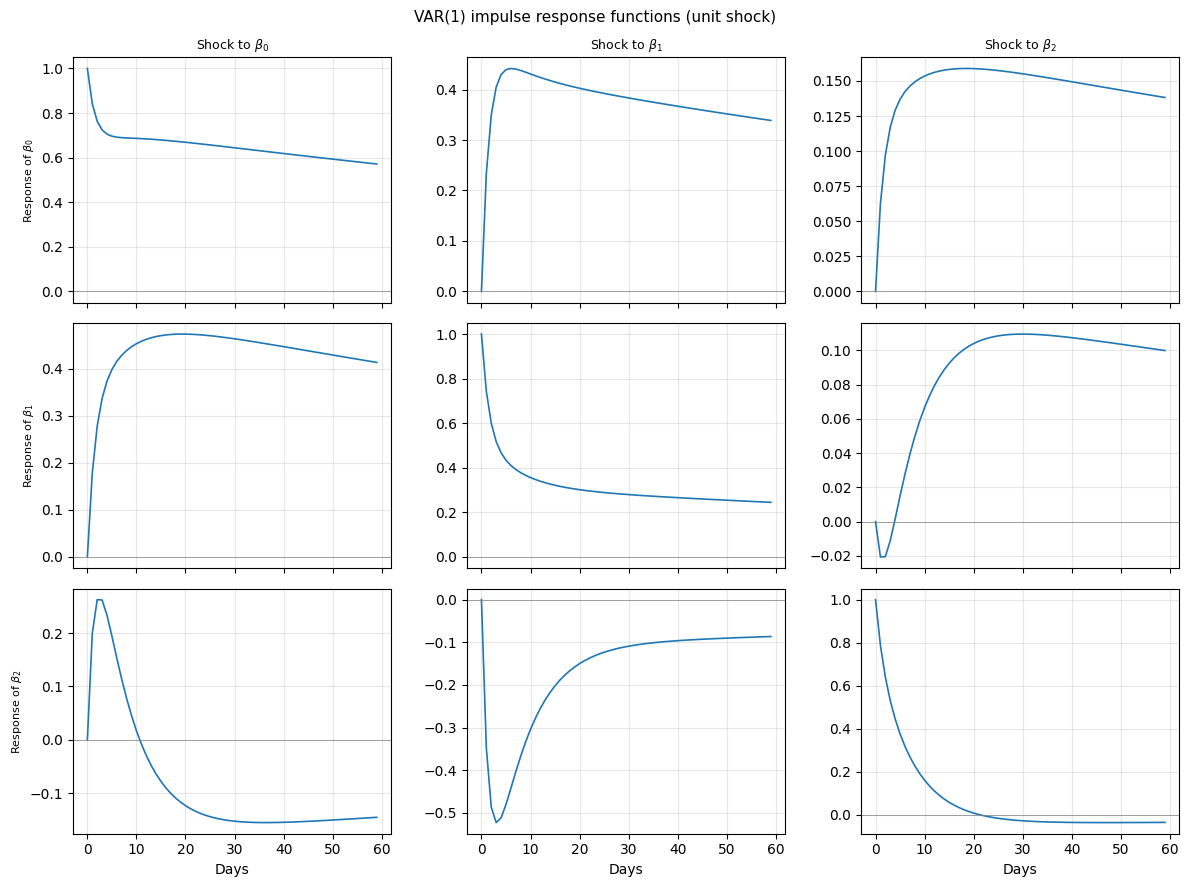

In [ ]:
# VAR(1) diagnostics
eigvals = npl.eigvals(Phi)
print("Phi eigenvalues (modulus):")
for ev in eigvals:
    print(f"  {ev:.4f}  (|.|={abs(ev):.4f}, half-life={-np.log(2)/np.log(abs(ev)):.1f} days)")
# Unconditional mean
X_ss = npl.solve(np.eye(3) - Phi, c_var)
print(f"\nUnconditional mean of factors:")
print(f"  beta0 = {X_ss[0]:.3f} (long-run yield level)")
print(f"  beta1 = {X_ss[1]:.3f} (long-run slope)")
print(f"  beta2 = {X_ss[2]:.3f} (long-run curvature)")
# Impulse response: shock to each factor, trace out 60-day response
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
horizon = 60
factor_names = [r"$\beta_0$", r"$\beta_1$", r"$\beta_2$"]
for j_shock in range(3):  # which factor gets shocked
    impulse = np.zeros(3)
    impulse[j_shock] = 1.0  # unit shock
    response = np.zeros((horizon, 3))
    response[0] = impulse
    for h in range(1, horizon):
        response[h] = Phi @ response[h - 1]
    for j_resp in range(3):  # which factor responds
        ax = axes[j_resp, j_shock]
        ax.plot(response[:, j_resp], linewidth=1.2)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.grid(True, alpha=0.3)
        if j_resp == 0:
            ax.set_title(f"Shock to {factor_names[j_shock]}", fontsize=9)
        if j_shock == 0:
            ax.set_ylabel(f"Response of {factor_names[j_resp]}", fontsize=8)
        if j_resp == 2:
            ax.set_xlabel("Days")
fig.suptitle("VAR(1) impulse response functions (unit shock)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join("report/output/kalman_irf.pdf"))
plt.show(); plt.close(fig)

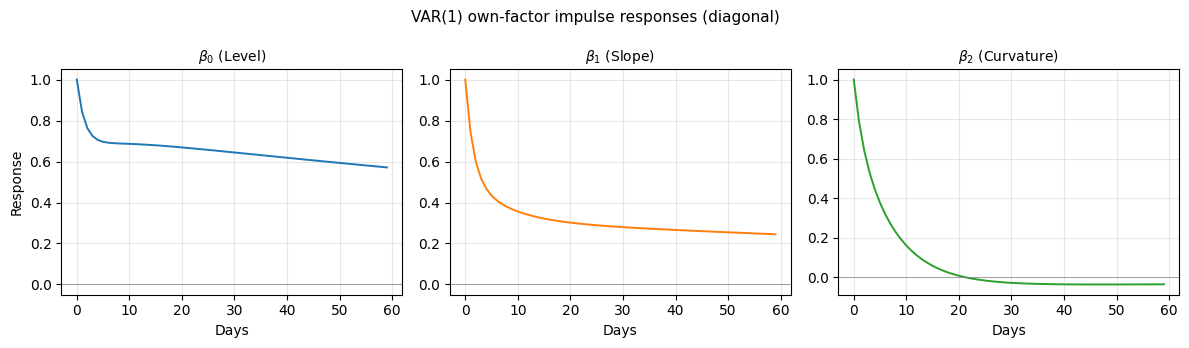

In [ ]:
# ── Diagonal IRFs only (own-factor responses) ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)
factor_names = [r"$\beta_0$", r"$\beta_1$", r"$\beta_2$"]
subtitles = ["Level", "Slope", "Curvature"]

for j in range(3):
    impulse = np.zeros(3)
    impulse[j] = 1.0
    response = np.zeros((horizon, 3))
    response[0] = impulse
    for h in range(1, horizon):
        response[h] = Phi @ response[h - 1]

    ax = axes[j]
    ax.plot(response[:, j], linewidth=1.4, color=f"C{j}")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"{factor_names[j]} ({subtitles[j]})", fontsize=10)
    ax.set_xlabel("Days")
    ax.set_ylabel("Response" if j == 0 else "")
    ax.grid(True, alpha=0.3)

fig.suptitle("VAR(1) own-factor impulse responses (diagonal)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join("report/output/kalman_irf_diagonal.pdf"))
plt.show(); plt.close(fig)

---

## Plots
All figures are rendered inline in this notebook (no file export).

# Part (E) - Applications: forecasting with Dynamic Nelson–Siegel

We compare DNS to simple benchmarks for **changes** in 2y, 5y, and 10y zero-coupon yields. With a **rolling 3-year window**, we report out-of-sample RMSE of yield changes at **daily (1d)**, **weekly (5d)**, and **monthly (21 business days)** horizons:

- **RW**: random walk (forecast change = 0).
- **AR(1)**: univariate AR(1) per maturity, multi-step forecasts.
- **DNS–Kalman**: VAR(1) + Kalman from Part (D), re-estimated each window; multi-step factor forecasts mapped to yields.

The next cell shows a **summary table** and a **grouped bar chart**, saved as `report/output/partE_rmse_daily_weekly_monthly.pdf`.

/var/folders/yg/wy4j3dxj33z_991wlb79hlvc0000gn/T/ipykernel_42873/4024858336.py:53: RuntimeWarning: invalid value encountered in log
  + np.log(npl.det(S))


model                        AR(1)  DNS-Kalman      RW
horizon       maturity (y)                            
1d (daily)    2.0           0.0588      0.1118  0.0585
              5.0           0.0612      0.0908  0.0610
              10.0          0.0603      0.1200  0.0602
21d (monthly) 2.0           0.3076      0.4961  0.2791
              5.0           0.2922      0.4056  0.2735
              10.0          0.2868      0.4274  0.2717
5d (weekly)   2.0           0.1317      0.2690  0.1280
              5.0           0.1333      0.1935  0.1312
              10.0          0.1313      0.2430  0.1296

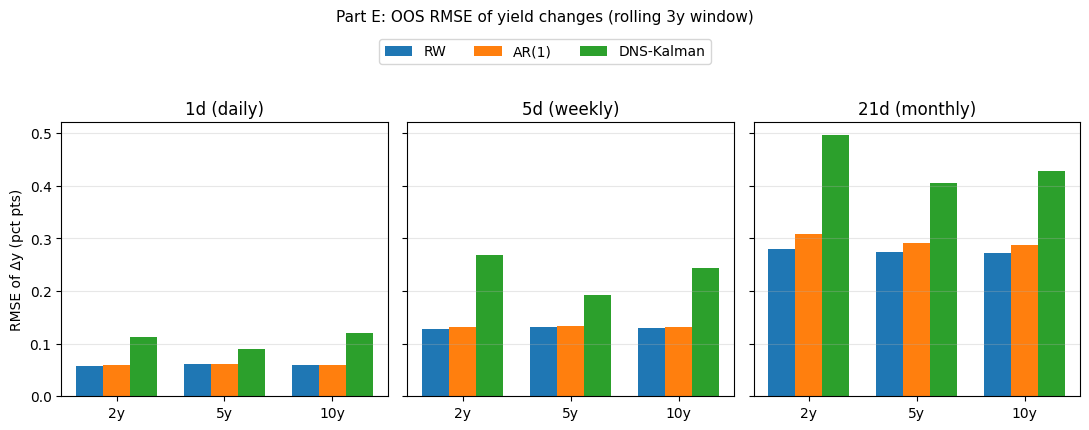

Saved: report/output/partE_rmse_daily_weekly_monthly.pdf


In [ ]:
import collections

# Part (E) - Rolling forecasts of yield changes (1d, 5d, 21d)

# Horizons in business days
HORIZONS = [1, 5, 21]
HORIZON_LABELS = {1: "1d (daily)", 5: "5d (weekly)", 21: "21d (monthly)"}

# Target maturities (in years) and their indices in TENORS
TARGET_MATS = [2.0, 5.0, 10.0]
mat_idx = {T: int(np.where(TENORS == T)[0][0]) for T in TARGET_MATS}

# Rolling window length ~ 3 years of business days
WINDOW_DAYS = 3 * 252
N = Y_mat.shape[0]
max_h = max(HORIZONS)

# Container for squared forecast errors of yield changes
se = collections.defaultdict(list)  # keys: (horizon, maturity, model)

# Loop over forecast origin dates t
for t in range(WINDOW_DAYS, N - max_h):
    # Re-estimate AR(1) on each maturity using previous 3 years (including y_t)
    ar_params = {}
    for T in TARGET_MATS:
        j = mat_idx[T]
        y_hist = Y_mat[t - WINDOW_DAYS : t + 1, j]  # length WINDOW_DAYS+1
        # y_{s+1} = a + b y_s
        X_ar = np.column_stack([
            np.ones(WINDOW_DAYS, dtype=float),
            y_hist[:-1],
        ])
        y_ar = y_hist[1:]
        ab, _, _, _ = npl.lstsq(X_ar, y_ar, rcond=None)
        ar_params[T] = ab  # (a, b)

    # Re-estimate VAR(1) on NS factors using previous 3 years (including X_t)
    X_win = X_ols[t - WINDOW_DAYS : t + 1]  # (W+1 x 3)
    X_prev = X_win[:-1]
    X_cur = X_win[1:]
    Z_var = np.column_stack([np.ones(len(X_prev)), X_prev])
    coeffs_win = npl.lstsq(Z_var, X_cur, rcond=None)[0]  # (4 x 3)
    c_win = coeffs_win[0]
    Phi_win = coeffs_win[1:].T
    eta_win = X_cur - Z_var @ coeffs_win
    Q_win = (eta_win.T @ eta_win) / (len(eta_win) - 4)

    # Short Kalman filter on the same window to get filtered state at t
    Y_win = Y_mat[t - WINDOW_DAYS : t + 1]
    X_f_win, _, _, _, _ = kalman_filter(Y_win, Lambda, c_win, Phi_win, Q_win, R)
    x_t_filt = X_f_win[-1]

    # For each horizon and maturity, compute forecast errors of yield changes
    for h in HORIZONS:
        if t + h >= N:
            continue
        # DNS–Kalman multi-step factor forecast
        x_fore = x_t_filt.copy()
        for _ in range(h):
            x_fore = c_win + Phi_win @ x_fore
        y_dns_fore = Lambda @ x_fore  # 8x1

        for T in TARGET_MATS:
            j = mat_idx[T]
            y_t = Y_mat[t, j]
            y_th = Y_mat[t + h, j]
            dy_actual = y_th - y_t

            # 1) Random walk: forecast change = 0
            se[(h, T, "RW")].append(dy_actual ** 2)

            # 2) AR(1): use h-step closed-form forecast
            a, b = ar_params[T]
            if abs(1.0 - b) < 1e-8:
                y_ar_fore = y_t + h * a  # near-unit-root fallback
            else:
                y_ar_fore = a * (1.0 - b ** h) / (1.0 - b) + (b ** h) * y_t
            dy_ar_fore = y_ar_fore - y_t
            se[(h, T, "AR(1)")].append((dy_ar_fore - dy_actual) ** 2)

            # 3) DNS–Kalman: forecast from filtered factors
            dy_dns_fore = y_dns_fore[j] - y_t
            se[(h, T, "DNS-Kalman")].append((dy_dns_fore - dy_actual) ** 2)

# Build RMSE summary table
rows = []
for h in HORIZONS:
    for T in TARGET_MATS:
        for model in ["RW", "AR(1)", "DNS-Kalman"]:
            key = (h, T, model)
            if key in se and len(se[key]) > 0:
                rmse = float(np.sqrt(np.mean(se[key])))
                rows.append({
                    "horizon": HORIZON_LABELS[h],
                    "maturity (y)": T,
                    "model": model,
                    "RMSE of Δy (pct-pts)": rmse,
                })

rmse_table = pd.DataFrame(rows)
rmse_table_pivot = rmse_table.pivot_table(
    index=["horizon", "maturity (y)"],
    columns="model",
    values="RMSE of Δy (pct-pts)",
).sort_index()

# Summary table
try:
    from IPython.display import display
except ImportError:
    display = print
display(rmse_table_pivot.round(4))

# Grouped bar chart: daily / weekly / monthly × maturities × models
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
model_order = ["RW", "AR(1)", "DNS-Kalman"]
x = np.arange(len(TARGET_MATS))
width = 0.25
for ax, h in zip(axes, HORIZONS):
    lab = HORIZON_LABELS[h]
    for k, model in enumerate(model_order):
        vals = [
            float(rmse_table_pivot.loc[(lab, T), model])
            for T in TARGET_MATS
        ]
        ax.bar(x + (k - 1) * width, vals, width, label=model)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(T)}y" for T in TARGET_MATS])
    ax.set_title(lab)
    ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("RMSE of Δy (pct pts)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(
    "Part E: OOS RMSE of yield changes (rolling 3y window)",
    fontsize=11,
    y=1.12,
)
fig.tight_layout()
out_path = os.path.join("report/output/partE_rmse_daily_weekly_monthly.pdf")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", out_path)